In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import pickle
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score, brier_score_loss, precision_recall_curve
from sklearn.model_selection import ParameterGrid
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve, CalibrationDisplay
from expl_perf_drop.explainers import CGExplainerDR
from expl_perf_drop.utils import Graph
from tqdm.notebook import tqdm
tqdm.pandas()

print(datetime.datetime.now())


Initializing package . . . 😘


2025-06-08 19:50:54.042942


# Data processing

In [2]:
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

def agg_window_fast(window_df: pd.DataFrame):
    """
    window_df: columns=['offset','itemid','value']
    pivot -> shape=(#unique offset, #unique itemid)
    Then for each column(itemid), compute stats (mean, max, ...)
    """
    if window_df.empty:
        return {}

    pivoted = window_df.pivot(index='offset', columns='itemid', values='value')
    # pivoted: offset x itemid
    # col별 => mean, max, min, ...
    stats_dict = {}
    col_names = pivoted.columns
    means = pivoted.mean(axis=0)
    maxs  = pivoted.max(axis=0)
    mins  = pivoted.min(axis=0)
    stds  = pivoted.std(axis=0)
    meds  = pivoted.median(axis=0)
    q25s  = pivoted.quantile(0.25, axis=0)
    q75s  = pivoted.quantile(0.75, axis=0)
    counts = pivoted.count(axis=0)

    for item in col_names:
        # skip if all NaN?
        # or do if counts[item]==0 => skip
        rng = maxs[item] - mins[item] if counts[item]>0 else np.nan
        stats_dict[f'{item}_mean'] = means[item]
        stats_dict[f'{item}_max']  = maxs[item]
        stats_dict[f'{item}_min']  = mins[item]
        stats_dict[f'{item}_std']  = stds[item]
        stats_dict[f'{item}_median'] = meds[item]
        stats_dict[f'{item}_q25'] = q25s[item]
        stats_dict[f'{item}_q75'] = q75s[item]
        stats_dict[f'{item}_range'] = rng
        stats_dict[f'{item}_count'] = counts[item]

    return stats_dict


def get_clip_bounds_from_train(train_df: pd.DataFrame, binary_itemids: set, trim_percentile=0.01):
    """
    Train 데이터로부터 각 itemid별 (lower, upper) clip bound를 계산.
    binary_itemids는 trimming 제외.
    
    반환:
      clip_bounds: dict(itemid -> (lower, upper))
    """

    clip_bounds = {}
    for item_id, grp in train_df.groupby('itemid'):
        if item_id in binary_itemids:
            continue
        lower = grp['value'].quantile(trim_percentile)
        upper = grp['value'].quantile(1 - trim_percentile)
        clip_bounds[item_id] = (lower, upper)
    
    return clip_bounds

def apply_clip_bounds(df: pd.DataFrame, binary_itemids: set, clip_bounds: dict):
    """
    df를 itemid별로 나누어, clip_bounds가 있는 경우 그 범위 내로 trimming.
    binary itemid는 trimming 없이 그대로.
    """

    trimmed_parts = []
    for item_id, grp in df.groupby('itemid'):
        if item_id in binary_itemids:
            trimmed_parts.append(grp)
        else:
            if item_id in clip_bounds:
                l, u = clip_bounds[item_id]
                clipped = grp[(grp['value']>=l)&(grp['value']<=u)]
                trimmed_parts.append(clipped)
            else:
                trimmed_parts.append(grp)
    return pd.concat(trimmed_parts, ignore_index=True)


def aggregate_time_series_features_aki_stepwise(
    df: pd.DataFrame,
    outcome_df: pd.DataFrame,
    obs_window: int = 48*60,   # default 48시간
    step: int = 60,           # default 1시간 간격
    trim_percentile: float = 0.01
):
    """
    1) df ([hadm_id, offset, itemid, value])에 대해
       hadm_id별로 max_offset까지 step 간격으로 query_time을 생성.
       - window = [query_time, query_time + obs_window)
       - window 내 itemid별 통계를 계산( mean, max, min, etc... ).
    2) outcome_df ([hadm_id, aki_offset])를 이용해 aki 라벨링:
       - aki_offset이 window 안([wstart, wend]) 혹은 이전이면 => 해당 행 skip
       - aki_offset이 (wend, wend+480] 내에 있으면 => aki_label=1, else=0

    Returns:
      DataFrame: 각 (hadm_id, query_time) 별로 itemid 통계가 열이 되고,
                 aki_label 열이 추가됨.

    [주의] Trimming, 이진 변수 식별 등은 외부에서 해주세요.
    """

    # ------------------------
    # 0) Data 복사
    # ------------------------
    df_filtered = df.copy()

  
    # ------------------------
    # C) outcome_df -> dict {hadm_id: aki_offset}
    # ------------------------

    hadm2aki = {}

    for _, row in outcome_df.iterrows():
        hid = row['hadm_id']
        # 여러 onset의 리스트여야 함; 만약 NaN이면 빈 리스트로 설정
        coffs = row['aki_offset']
        if isinstance(coffs, (list, np.ndarray)):
            # 만약 배열 전체가 NaN이면 빈 리스트로 설정
            if np.all(pd.isna(coffs)):
                coffs = []
        else:
            if pd.isna(coffs):
                coffs = []
        hadm2aki[hid] = coffs


    # ------------------------
    # E) hadm_id별로 step 윈도우 + aki 라벨링
    # ------------------------
    results = []

    hadm_groups = df_filtered.groupby('hadm_id')
    for hadm_id, group in tqdm(hadm_groups, desc="[aggregate aki stepwise]"):
        if group.empty:
            continue

        # aki_offset for this hadm
        aki_onsets = hadm2aki.get(hadm_id, [])
        if aki_onsets and isinstance(aki_onsets[0], list):
            flat = []
            for sub in aki_onsets:
                flat.extend(sub)
            aki_onsets = flat
        max_offset = group['offset'].max()

        if max_offset < obs_window:
            continue
        qtimes = [obs_window]



        for qtime in qtimes:
            win_start = qtime - obs_window
            win_end   = qtime 
            # 1) 윈도우 dataframe
            obs_window_df = group[(group['offset']>win_start) & (group['offset']<=win_end)].copy()
            if obs_window_df.empty or obs_window_df.shape[0]<10:
                continue

            aki_label = 0
            if any((onset > win_end) and (onset <= win_end + 480) for onset in aki_onsets):
                aki_label = 1

            # 4) itemid별로 통계 계산
            row_dict = {
                'hadm_id': hadm_id,
                'query_time': qtime,
                'outcome': aki_label
            }

            stats_dict = agg_window_fast(obs_window_df[['offset','itemid','value']])
            row_dict.update(stats_dict)

            results.append(row_dict)

    # ------------------------
    # F) 결과 DataFrame
    # ------------------------
    final_df = pd.DataFrame(results)
    if final_df.empty:
        print("[aggregate_time_series_features_aki_stepwise] No data generated.")
        return final_df

    # 편의상 hadm_id, query_time, aki_label 순으로 정렬
    base_cols = ['hadm_id', 'query_time', 'outcome']
    other_cols = [c for c in final_df.columns if c not in base_cols]
    final_cols = base_cols + other_cols
    final_df = final_df[final_cols]

    return final_df

In [3]:
# Use Age, gender, height

mimic_static = pd.read_feather('mimic_data_static.feather')
# Gender is 1 for male, 0 for female
mimic_static['gender'] = (mimic_static['gender'] == 'M').astype(int)

# Change height to cm (*2.54)
mimic_static['height'] = mimic_static['height'] * 2.54


# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

# (1) clip_bounds
with open('clip_bounds.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

reverse_item_dict = {v: k for k, v in item_dict_total.items()}

# 새로운 dict를 생성하여, clip_bounds_all의 key를 원래 변수명으로 변경합니다.
clip_bounds = {}
for encoded_key, bounds in clip_bounds_all.items():
    original_name = reverse_item_dict.get(encoded_key, encoded_key)  # 매핑이 없으면 그대로 사용
    clip_bounds[original_name] = bounds

def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    print(len(static[static['outtime'] >= static['deathtime']]))
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

mimic_outcome, mimic_ids = process_static(mimic_static)

data_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'})

data = pd.concat([data_vital, data_lab, data_treatment])

# Factorize the 'item' column and get the mapping
encoded_total, actual_class_total = pd.factorize(data['itemid'])
# data.loc[:,'itemid'] = encoded_total.astype(int)
# data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

item_dict_total = dict(zip(actual_class_total, range(len(actual_class_total))))
emb_idx_total = len(item_dict_total)

train_outcome_df = pd.read_feather('./model_results/train_aki_outcome.feather')
valid_outcome_df = pd.read_feather('./model_results/valid_aki_outcome.feather')
test_outcome_df = pd.read_feather('./model_results/test_aki_outcome.feather')

train_outcome_df['aki_offset'] = train_outcome_df['aki_offset'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
valid_outcome_df['aki_offset'] = valid_outcome_df['aki_offset'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
test_outcome_df['aki_offset'] = test_outcome_df['aki_offset'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(mimic_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(mimic_ids) * 0.6)
valid_size = int(len(mimic_ids) * 0.8)
train_hadm_ids = mimic_ids[:train_size]
valid_hadm_ids = mimic_ids[train_size:valid_size]
test_hadm_ids = mimic_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids

# (D) 최종 DF
train_df = data[data['hadm_id'].isin(train_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)

# 1) 이진 변수는 'Train'에서 식별(또는 전체 df)
train_binary_itemids = set()
for item_id, grp in train_df.groupby('itemid'):
    uniq = set(grp['value'].dropna().unique())
    if uniq.issubset({0,1}):
        train_binary_itemids.add(item_id)
print("[binary item ids]", train_binary_itemids)


# 3) Train/Valid/Test 각각 trimming
train_df_trim = apply_clip_bounds(train_df, train_binary_itemids, clip_bounds)
valid_df_trim = apply_clip_bounds(valid_df, train_binary_itemids, clip_bounds)
test_df_trim  = apply_clip_bounds(test_df,  train_binary_itemids, clip_bounds)

train_df = aggregate_time_series_features_aki_stepwise(
    train_df_trim, train_outcome_df,
    obs_window=48*60,
    step=2*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
train_df = train_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')

valid_df = aggregate_time_series_features_aki_stepwise(
    valid_df_trim, valid_outcome_df,
    obs_window=48*60,
    step=2*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
valid_df = valid_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


test_df = aggregate_time_series_features_aki_stepwise(
    test_df_trim, test_outcome_df,
    obs_window=48*60,
    step=2*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
test_df = test_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


valid_df = valid_df.reindex(columns=train_df.columns, fill_value=np.nan)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=np.nan)

print(datetime.datetime.now())

3734


[binary item ids] {'h', 'ventilator', 'r', 'n', 'a_drug', 'c01', 'm', 'fluid', 'b', 'v', 'a_supplements', 'c_else', 'antibiotics', 'l', 'a10'}


[aggregate aki stepwise]:   0%|          | 0/32606 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/10869 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/10869 [00:00<?, ?it/s]

2025-06-08 19:54:31.706539


In [4]:
# eICU
# embs_varwise
# Less samples because
# Use Age, gender, height

eicu_static = pd.read_feather('eicu_data_static.feather')

eicu_static = eicu_static.rename(columns={'admissionheight' : 'height', 'patientunitstayid' : 'hadm_id'})
# Gender is 1 for male, 0 for female
eicu_static['gender'] = (eicu_static['gender'] == 'Male').astype(int)
eicu_ids = eicu_static['hadm_id'].unique()


data_vital_eicu = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})
data_lab_eicu = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})
data_treatment_eicu = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})

data_eicu = pd.concat([data_vital_eicu, data_lab_eicu, data_treatment_eicu])

data_eicu = data_eicu.dropna(subset=['value'])
data_eicu_stats = calculate_all_stats(data_eicu)

item_dict_total = dict(zip(actual_class_total, range(len(actual_class_total))))
emb_idx_total = len(item_dict_total)

train_outcome_df_eicu = pd.read_feather('./model_results/train_aki_outcome_eicu.feather')
valid_outcome_df_eicu = pd.read_feather('./model_results/valid_aki_outcome_eicu.feather')
test_outcome_df_eicu = pd.read_feather('./model_results/test_aki_outcome_eicu.feather')

train_outcome_df_eicu['aki_offset'] = train_outcome_df_eicu['aki_offset'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
valid_outcome_df_eicu['aki_offset'] = valid_outcome_df_eicu['aki_offset'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
test_outcome_df_eicu['aki_offset'] = test_outcome_df_eicu['aki_offset'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(eicu_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(eicu_ids) * 0.6)
valid_size = int(len(eicu_ids) * 0.8)
train_hadm_ids = eicu_ids[:train_size]
valid_hadm_ids = eicu_ids[train_size:valid_size]
test_hadm_ids = eicu_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids

# (D) 최종 DF_eicu
train_df_eicu = data_eicu[data_eicu['hadm_id'].isin(train_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
valid_df_eicu = data_eicu[data_eicu['hadm_id'].isin(valid_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
test_df_eicu = data_eicu[data_eicu['hadm_id'].isin(test_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)

# 1) 이진 변수는 'Train'에서 식별(또는 전체 df_eicu)
train_binary_itemids = set()
for item_id, grp in train_df_eicu.groupby('itemid'):
    uniq = set(grp['value'].dropna().unique())
    if uniq.issubset({0,1}):
        train_binary_itemids.add(item_id)
print("[binary item ids]", train_binary_itemids)


# 3) Train/Valid/Test 각각 trimming
train_df_eicu_trim = apply_clip_bounds(train_df_eicu, train_binary_itemids, clip_bounds)
valid_df_eicu_trim = apply_clip_bounds(valid_df_eicu, train_binary_itemids, clip_bounds)
test_df_eicu_trim  = apply_clip_bounds(test_df_eicu,  train_binary_itemids, clip_bounds)

train_df_eicu = aggregate_time_series_features_aki_stepwise(
    train_df_eicu_trim, train_outcome_df_eicu,
    obs_window=48*60,
    step=2*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
train_df_eicu = train_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')

valid_df_eicu = aggregate_time_series_features_aki_stepwise(
    valid_df_eicu_trim, valid_outcome_df_eicu,
    obs_window=48*60,
    step=2*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
valid_df_eicu = valid_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


test_df_eicu = aggregate_time_series_features_aki_stepwise(
    test_df_eicu_trim, test_outcome_df_eicu,
    obs_window=48*60,
    step=2*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
test_df_eicu = test_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


valid_df_eicu = valid_df_eicu.reindex(columns=train_df_eicu.columns, fill_value=np.nan)
test_df_eicu  = test_df_eicu.reindex(columns=train_df_eicu.columns, fill_value=np.nan)

print(datetime.datetime.now())



[binary item ids] {'antibiotic', 'h', 'ventilator', 'r', 'n', 'a_drug', 'm', 'fluid', 'b', 'v', 'a_supplements', 'c_else', 'c01', 'l', 'a10'}


[aggregate aki stepwise]:   0%|          | 0/36437 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/12146 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/12146 [00:00<?, ?it/s]

2025-06-08 20:02:19.235068


In [5]:
# save_directory = './stats_df/'

# train_df.to_feather(f'{save_directory}train_df.feather')
# valid_df.to_feather(f'{save_directory}valid_df.feather')
# test_df.to_feather(f'{save_directory}test_df.feather')

# train_df_eicu.to_feather(f'{save_directory}train_df_eicu.feather')
# valid_df_eicu.to_feather(f'{save_directory}valid_df_eicu.feather')
# test_df_eicu.to_feather(f'{save_directory}test_df_eicu.feather')


In [6]:
# save_directory = './stats_df/'
# train_df = pd.read_feather(f'{save_directory}train_df.feather')
# valid_df = pd.read_feather(f'{save_directory}valid_df.feather')
# test_df = pd.read_feather(f'{save_directory}test_df.feather')

# train_df_eicu = pd.read_feather(f'{save_directory}train_df_eicu.feather')
# valid_df_eicu = pd.read_feather(f'{save_directory}valid_df_eicu.feather')
# test_df_eicu = pd.read_feather(f'{save_directory}test_df_eicu.feather')


In [7]:
train_emb_df = pd.read_csv('./model_results/train_embedding_eicu_aki48.csv')
valid_emb_df = pd.read_csv('./model_results/valid_embedding_eicu_aki48.csv')
test_emb_df = pd.read_csv('./model_results/test_embedding_eicu_aki48.csv')

In [8]:
train_emb_df = pd.read_csv('./model_results/train_embedding_eicu_aki48.csv')
valid_emb_df = pd.read_csv('./model_results/valid_embedding_eicu_aki48.csv')
test_emb_df = pd.read_csv('./model_results/test_embedding_eicu_aki48.csv')

train_emb_df = pd.merge(
    train_emb_df, 
    train_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

train_emb_df = train_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

train_emb_df = train_emb_df.drop(columns=['hadm_id','query_time'])


valid_emb_df = pd.merge(
    valid_emb_df, 
    valid_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

valid_emb_df = valid_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_emb_df = valid_emb_df.drop(columns=['hadm_id','query_time'])

test_emb_df = pd.merge(
    test_emb_df, 
    test_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

test_emb_df = test_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_emb_df = test_emb_df.drop(columns=['hadm_id','query_time'])

# train_emb_df['outcome'] = train_df_eicu['outcome'].values
# valid_emb_df['outcome'] = valid_df_eicu['outcome'].values
# test_emb_df['outcome'] = test_df_eicu['outcome'].values

In [9]:
# eicu
# embs_varwise
# Less samples because

train_vital_df = pd.read_csv('./model_results/train_embedding_eicu_vital_aki48.csv').sort_values(by=['hadm_id','query_time'])
train_lab_df = pd.read_csv('./model_results/train_embedding_eicu_lab_aki48.csv').sort_values(by=['hadm_id','query_time'])
train_treat_df = pd.read_csv('./model_results/train_embedding_eicu_treatment_aki48.csv').sort_values(by=['hadm_id','query_time'])

train_vars_df = pd.merge(train_vital_df, train_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
train_vars_df = pd.merge(train_vars_df, train_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_vital_df = pd.read_csv('./model_results/valid_embedding_eicu_vital_aki48.csv').sort_values(by=['hadm_id','query_time'])
valid_lab_df = pd.read_csv('./model_results/valid_embedding_eicu_lab_aki48.csv').sort_values(by=['hadm_id','query_time'])
valid_treat_df = pd.read_csv('./model_results/valid_embedding_eicu_treatment_aki48.csv').sort_values(by=['hadm_id','query_time'])

valid_vars_df = pd.merge(valid_vital_df, valid_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
valid_vars_df = pd.merge(valid_vars_df, valid_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_vital_df = pd.read_csv('./model_results/test_embedding_eicu_vital_aki48.csv').sort_values(by=['hadm_id','query_time'])
test_lab_df = pd.read_csv('./model_results/test_embedding_eicu_lab_aki48.csv').sort_values(by=['hadm_id','query_time'])
test_treat_df = pd.read_csv('./model_results/test_embedding_eicu_treatment_aki48.csv').sort_values(by=['hadm_id','query_time'])

test_vars_df = pd.merge(test_vital_df, test_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
test_vars_df = pd.merge(test_vars_df, test_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)

train_vars_df = pd.merge(
    train_vars_df, 
    train_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 train_vars_df에는 “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
train_vars_df = train_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)
train_vars_df.to_feather('eicu_trained_eicu_aki_train.feather')


# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
train_vars_df = train_vars_df.drop(columns=['hadm_id','query_time'])
train_df_eicu = train_df_eicu.drop(columns=['hadm_id','query_time'])


valid_vars_df = pd.merge(
    valid_vars_df, 
    valid_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 valid_vars_df “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
valid_vars_df = valid_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)
valid_vars_df.to_feather('eicu_trained_eicu_aki_valid.feather')


# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
valid_vars_df = valid_vars_df.drop(columns=['hadm_id','query_time'])
valid_df_eicu = valid_df_eicu.drop(columns=['hadm_id','query_time'])

test_vars_df = pd.merge(
    test_vars_df, 
    test_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 test_vars_df “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
test_vars_df = test_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)
test_vars_df.to_feather('eicu_trained_eicu_aki_test.feather')

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
test_vars_df = test_vars_df.drop(columns=['hadm_id','query_time'])
test_df_eicu = test_df_eicu.drop(columns=['hadm_id','query_time'])


In [10]:

train_vital_df_mimic = pd.read_csv('./model_results/train_embedding_mimic_vital_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])
train_lab_df_mimic = pd.read_csv('./model_results/train_embedding_mimic_lab_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])
train_treat_df_mimic = pd.read_csv('./model_results/train_embedding_mimic_treatment_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])

train_vars_df_mimic = pd.merge(train_vital_df_mimic, train_lab_df_mimic, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
train_vars_df_mimic = pd.merge(train_vars_df_mimic, train_treat_df_mimic, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_vital_df_mimic = pd.read_csv('./model_results/valid_embedding_mimic_vital_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])
valid_lab_df_mimic = pd.read_csv('./model_results/valid_embedding_mimic_lab_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])
valid_treat_df_mimic = pd.read_csv('./model_results/valid_embedding_mimic_treatment_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])

valid_vars_df_mimic = pd.merge(valid_vital_df_mimic, valid_lab_df_mimic, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
valid_vars_df_mimic = pd.merge(valid_vars_df_mimic, valid_treat_df_mimic, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_vital_df_mimic = pd.read_csv('./model_results/test_embedding_mimic_vital_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])
test_lab_df_mimic = pd.read_csv('./model_results/test_embedding_mimic_lab_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])
test_treat_df_mimic = pd.read_csv('./model_results/test_embedding_mimic_treatment_aki48_inference.csv').sort_values(by=['hadm_id','query_time'])

test_vars_df_mimic = pd.merge(test_vital_df_mimic, test_lab_df_mimic, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
test_vars_df_mimic = pd.merge(test_vars_df_mimic, test_treat_df_mimic, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)

train_vars_df_mimic = pd.merge(
    train_vars_df_mimic, 
    train_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 train_vars_df_mimic에는 “train_df_mimic에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
train_vars_df_mimic = train_vars_df_mimic.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)
train_vars_df_mimic.to_feather('eicu_trained_mimic_aki_train.feather')


# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
train_vars_df_mimic = train_vars_df_mimic.drop(columns=['hadm_id','query_time'])
train_df = train_df.drop(columns=['hadm_id','query_time'])


valid_vars_df_mimic = pd.merge(
    valid_vars_df_mimic, 
    valid_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 valid_vars_df_mimic “train_df_mimic에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
valid_vars_df_mimic = valid_vars_df_mimic.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)
valid_vars_df_mimic.to_feather('eicu_trained_mimic_aki_valid.feather')


# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
valid_vars_df_mimic = valid_vars_df_mimic.drop(columns=['hadm_id','query_time'])
valid_df = valid_df.drop(columns=['hadm_id','query_time'])

test_vars_df_mimic = pd.merge(
    test_vars_df_mimic, 
    test_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 test_vars_df_mimic “train_df_mimic에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
test_vars_df_mimic = test_vars_df_mimic.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)
test_vars_df_mimic.to_feather('eicu_trained_mimic_aki_test.feather')

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
test_vars_df_mimic = test_vars_df_mimic.drop(columns=['hadm_id','query_time'])
test_df = test_df.drop(columns=['hadm_id','query_time'])


In [11]:
print(len(train_vars_df), len(train_vars_df_mimic))
print(len(valid_vars_df), len(valid_vars_df_mimic))
print(len(test_vars_df), len(test_vars_df_mimic))

35865 19827
11929 6784
11939 6656


# Representation modules

# Downstream modules

Input of the downstream modules for stay 'i' should be in form [rep1, rep2, ... , i_outcome]

In [12]:
valid_df = valid_df.reindex(columns=train_df.columns, fill_value=np.nan)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=np.nan)

In [13]:
train_vars_df = train_vars_df.dropna()
valid_vars_df = valid_vars_df.dropna()
test_vars_df = test_vars_df.dropna()

train_vars_df_mimic = train_vars_df_mimic.dropna()
valid_vars_df_mimic = valid_vars_df_mimic.dropna()
test_vars_df_mimic = test_vars_df_mimic.dropna()

print(train_vars_df['outcome'].value_counts())
print(train_vars_df_mimic['outcome'].value_counts())
print(valid_vars_df['outcome'].value_counts())
print(valid_vars_df_mimic['outcome'].value_counts())
print(test_vars_df['outcome'].value_counts())
print(test_vars_df_mimic['outcome'].value_counts())

outcome
0    18710
1     2560
Name: count, dtype: int64
outcome
0    14453
1     3187
Name: count, dtype: int64
outcome
0    6236
1     836
Name: count, dtype: int64
outcome
0    4936
1    1067
Name: count, dtype: int64
outcome
0    6289
1     844
Name: count, dtype: int64
outcome
0    4854
1    1047
Name: count, dtype: int64


In [14]:
class TwoLayerMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float = 0.5):
        super().__init__()
        # 첫 번째 은닉층
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act1 = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        # 두 번째 은닉층 → 출력 1개 (binary)
        self.fc2 = nn.Linear(hidden_dim, 1)
        # 최종 sigmoid는 loss 계산 시 BCEWithLogitsLoss 안에 포함하므로 forward에서는 로짓만 반환
    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.drop(x)
        logit = self.fc2(x)
        return logit  # (batch_size, 1)
    
def train_validate_mlp(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    input_dim: int,
    hidden_dim: int = 64,
    lr: float = 1e-3,
    batch_size: int = 64,
    epochs: int = 20,
    device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    patience: int = 5,
    save_path: str = None,
    verbose: bool = True
):
    """
    2-layer MLP을 PyTorch로 학습/검증/테스트하는 함수.
    train_df, valid_df, test_df 모두 'outcome' 열을 포함.
    input_dim: feature 차원
    hidden_dim: 은닉층 크기
    lr: learning rate
    batch_size: 배치 크기
    epochs: 최대 epoch
    patience: early stopping 위한 patience
    save_path: 모델 저장 경로 (None이면 저장하지 않음)
    """
    # 1) TensorDataset & DataLoader 준비
    def df_to_loader(df: pd.DataFrame, shuffle: bool):
        X = df.drop(columns=['outcome']).values.astype(np.float32)
        y = df['outcome'].values.astype(np.float32).reshape(-1, 1)
        dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    train_loader = df_to_loader(train_df, shuffle=True)
    valid_loader = df_to_loader(valid_df, shuffle=False)
    test_loader  = df_to_loader(test_df,  shuffle=False)

    # 2) 모델·손실·최적화기 초기화
    model = TwoLayerMLP(input_dim=input_dim, hidden_dim=hidden_dim, dropout=0.5).to(device)
    criterion = nn.BCEWithLogitsLoss()  # 내부에서 sigmoid + BCE
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_valid_auprc = -np.inf
    best_state_dict = None
    early_counter = 0

    # 기록용
    train_losses = []
    valid_auprcs = []
    valid_aurocs = []
    valid_losses = []

    for epoch in range(1, epochs + 1):
        # -------------------
        # (1) Training
        # -------------------
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)           # (batch_size,1)
            loss = criterion(logits, y_batch) # BCEWithLogitsLoss expects logits
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # -------------------
        # (2) Validation
        # -------------------
        model.eval()
        val_running_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_running_loss += loss.item() * X_batch.size(0)

                probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
                labels = y_batch.cpu().numpy().reshape(-1)
                all_preds.append(probs)
                all_labels.append(labels)

        epoch_valid_loss = val_running_loss / len(valid_loader.dataset)
        valid_losses.append(epoch_valid_loss)

        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        epoch_auprc = average_precision_score(all_labels, all_preds)
        epoch_auroc = roc_auc_score(all_labels, all_preds)
        valid_auprcs.append(epoch_auprc)
        valid_aurocs.append(epoch_auroc)

        if verbose:
            print(f"[Epoch {epoch}] "
                  f"Train Loss={epoch_train_loss:.4f}, "
                  f"Valid Loss={epoch_valid_loss:.4f}, "
                  f"Valid AUROC={epoch_auroc:.4f}, AUPRC={epoch_auprc:.4f}")

        # Early stopping 기준: Valid AUPRC
        if epoch_auprc > best_valid_auprc:
            best_valid_auprc = epoch_auprc
            best_state_dict = model.state_dict()
            early_counter = 0
        else:
            early_counter += 1
            if early_counter >= patience:
                if verbose:
                    print("Early stopping triggered.")
                break

    # 저장된 최적 모델 복원
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        if save_path is not None:
            torch.save(best_state_dict, save_path)

    # -------------------
    # (3) Test set 평가
    # -------------------
    model.eval()
    test_preds = []
    test_labels = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            labels = y_batch.cpu().numpy().reshape(-1)
            test_preds.append(probs)
            test_labels.append(labels)

    test_preds = np.concatenate(test_preds)
    test_labels = np.concatenate(test_labels)
    # 이진 분류 지표 계산
    test_y_pred = (test_preds >= 0.5).astype(int)

    brier = brier_score_loss(test_labels, test_preds)
    precisions, recalls, _ = precision_recall_curve(test_labels, test_preds)
    if np.any(recalls >= 0.8):
        precision_at_0_8 = np.max(precisions[recalls >= 0.8])
    else:
        precision_at_0_8 = np.nan

    test_metrics = {
        'AUROC': roc_auc_score(test_labels, test_preds),
        'AUPRC': average_precision_score(test_labels, test_preds),
        'Precision': precision_score(test_labels, test_y_pred),
        'Recall': recall_score(test_labels, test_y_pred),
        'F1': f1_score(test_labels, test_y_pred),
        'Accuracy': accuracy_score(test_labels, test_y_pred),
        'Brier': brier,
        'Precision@Recall_0.8': precision_at_0_8
    }



    if verbose:
        print("\n=== Test Metrics (MLP) ===")
        for k,v in test_metrics.items():
            print(f"{k}: {v:.4f}")

        prob_true, prob_pred = calibration_curve(test_labels, test_preds, n_bins=10)
        disp = CalibrationDisplay(prob_true, prob_pred, test_preds)
        disp.plot()

        # Precision-Recall curve (Test)
        plt.figure(figsize=(6,5))
        sns.lineplot(x=recalls, y=precisions, marker=',')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title("Precision-Recall Curve (Test, MLP)")
        plt.xlim(0,1); plt.ylim(0,1); plt.grid(True)
        plt.show()

    return model, test_metrics

def grid_search_train_and_evaluate_downstream_model(train, 
                                                      valid,
                                                      test,
                                                      param_grid,
                                                      model_name='downstream_model',
                                                      save_path=None,
                                                      verbose=True):
    """
    grid search로 downstream 모델의 하이퍼파라미터를 탐색하여, 
    validation set의 AUPRC가 가장 높은 모델을 선택하고 test set 성능을 평가하는 함수.
    
    Parameters:
      - train, valid, test: 각 데이터셋은 'outcome' 열을 포함한 DataFrame.
          'outcome' 열은 타겟 레이블(예: 이진 변수)을 의미하며,
          나머지 컬럼들은 모델의 feature로 사용됩니다.
      - param_grid: 탐색할 하이퍼파라미터의 dictionary 
                    (예: {'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}).
      - model_name: 저장 시 모델 파일 이름에 사용할 이름 (기본값 'downstream_model')
      - save_path: 모델 저장 경로 (디렉토리 또는 파일 경로). None이면 저장하지 않음.
      - verbose: 학습 및 평가 결과 출력 여부
      
    Returns:
      - best_model: 선택된 XGBClassifier 모델.
      - best_params: best_model의 하이퍼파라미터 dict.
      - best_valid_auprc: validation set에서 측정한 AUPRC 값.
      - test_metrics: test set에 대한 평가 지표가 담긴 dict 
                      (AUROC, AUPRC, Precision, Recall, F1, Accuracy, Brier, Precision@Recall_0.8)
    """
    # 데이터 분리 (feature와 target)
    x_train = train.drop(columns=['outcome'])
    y_train = train['outcome']
    x_valid = valid.drop(columns=['outcome'])
    y_valid = valid['outcome']
    x_test = test.drop(columns=['outcome'])
    y_test = test['outcome']
    
    best_valid_auprc = -np.inf
    best_params = None
    best_model = None

    # grid search 수행: param_grid의 모든 조합에 대해 모델 학습 및 validation 평가
    for params in ParameterGrid(param_grid):
        if verbose:
            print("Trying parameters:", params)
        # 모델 초기화 (추가 파라미터 전달, GPU 사용)
        model = xgb.XGBClassifier(tree_method='hist', device='cuda', **params)
        model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)
        
        # validation set에 대한 예측 수행
        valid_y_pred_proba = model.predict_proba(x_valid)[:, 1]
        valid_auprc = average_precision_score(y_valid, valid_y_pred_proba)
        if verbose:
            print("Validation AUPRC: {:.4f}".format(valid_auprc))
        
        # 가장 좋은 AUPRC를 가진 모델 선택
        if valid_auprc > best_valid_auprc:
            best_valid_auprc = valid_auprc
            best_params = params
            best_model = model

    # best_model을 사용하여 test set 평가
    y_pred_proba = best_model.predict_proba(x_test)[:, 1]
    y_pred = best_model.predict(x_test)
    
    # 추가: Brier Score 계산
    brier = brier_score_loss(y_test, y_pred_proba)
    
    # 추가: 특정 recall 수준 (여기서는 0.8)에서의 precision 계산
    target_recall = 0.8
    precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
    # recall이 target_recall 이상인 구간에서의 최대 precision 선택
    if np.any(recalls >= target_recall):
        precision_at_target = np.max(precisions[recalls >= target_recall])
    else:
        precision_at_target = np.nan

    test_metrics = {
        'AUROC': roc_auc_score(y_test, y_pred_proba),
        'AUPRC': average_precision_score(y_test, y_pred_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Brier': brier,
        'Precision@Recall_0.8': precision_at_target
    }
    

    print("\nBest Hyperparameters:", best_params)
    print("Best Validation AUPRC: {:.4f}".format(best_valid_auprc))
    print("\nTest Metrics for the Best Model:")
    for key, value in test_metrics.items():
        print(f"{key}: {value:.4f}")

    # Precision-Recall Curve 그리기 (Test Data)
    plt.figure(figsize=(8,6))
    sns.lineplot(x=recalls, y=precisions, marker=',')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve ({model_name})')
    plt.xlim(0, 1)  # x축 범위 고정
    plt.ylim(0, 1)  # y축 범위 고정
    plt.grid(True)
    plt.show()


    # 모델 저장 (save_path가 제공된 경우)
    if save_path is not None:
        if os.path.isdir(save_path):
            file_path = os.path.join(save_path, f"{model_name}.pkl")
        else:
            file_path = save_path

        with open(file_path, 'wb') as f:
            pickle.dump(best_model, f)

        print(f"Model saved to {file_path}")

    return best_model, best_params, best_valid_auprc, test_metrics

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    #'scale_pos_weight' : [1, 10, 24]
}

var_categories = { 
    'static' : ['age', 'height', 'gender'],
    'lab': [f'emb_{i}_lab' for i in range(32)],
    'treat': [f'emb_{i}' for i in range(32)],
    'vital': [f'emb_{i}_vital' for i in range(32)],
    'outcome': ['outcome']
}

def grid_search_train_and_evaluate_logistic(
    train: pd.DataFrame,
    valid: pd.DataFrame,
    test: pd.DataFrame,
    model_name: str = 'logistic_model',
    verbose: bool = True
):
    """
    Scikit-Learn LogisticRegression을 이용해 그리드 서치 후,
    validation AUPRC가 가장 높은 모델을 선택하고, 테스트 성능을 평가하는 함수.

    Parameters
    ----------
    train, valid, test : pandas.DataFrame
        각 DataFrame에는 반드시 'outcome' 열(0/1 이진 레이블)이 포함되어야 하고,
        나머지 열들은 모두 feature(숫자형)여야 합니다.
    param_grid : dict
        LogisticRegression에서 탐색할 하이퍼파라미터. 예)
          {'C': [0.01, 0.1, 1, 10],
           'penalty': ['l2'],
           'solver': ['liblinear', 'saga']}
    model_name : str
        모델 파일을 저장할 때 이름에 사용할 접두사 (default: 'logistic_model')
    save_path : str or None
        모델을 pickle로 저장할 경로(파일 또는 디렉토리). None이면 저장하지 않음.
    verbose : bool
        학습 과정 중 로그를 출력할지 여부.

    Returns
    -------
    best_model : sklearn.linear_model.LogisticRegression
        Validation AUPRC가 가장 좋았던 하이퍼파라미터로 학습된 모델.
    best_params : dict
        best_model의 하이퍼파라미터 값.
    best_valid_auprc : float
        검증 세트에서 기록된 최고 AUPRC 값.
    test_metrics : dict
        테스트 세트에 대한 평가 지표들:
            - 'AUROC', 'AUPRC', 'Precision', 'Recall', 'F1', 'Accuracy',
            - 'Brier', 'Precision@Recall_0.8'
    """
    # 1) feature / target 분리
    X_train = train.drop(columns=['outcome'])
    y_train = train['outcome']
    X_valid = valid.drop(columns=['outcome'])
    y_valid = valid['outcome']
    X_test  = test.drop(columns=['outcome'])
    y_test  = test['outcome']

    # 로지스틱 회귀 모델 초기화
    model = LogisticRegression(
        random_state=9871,            
    )

    # (a) Train
    model.fit(X_train, y_train)

    # 3) 테스트 세트 평가
    # best_model.predict_proba → (n_samples, 2) 중 [:,1] 확률 사용
    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred  = model.predict(X_test)

    # 각종 지표 계산
    brier = brier_score_loss(y_test, test_proba)

    precisions, recalls, _ = precision_recall_curve(y_test, test_proba)
    if np.any(recalls >= 0.8):
        precision_at_0_8 = np.max(precisions[recalls >= 0.8])
    else:
        precision_at_0_8 = np.nan

    test_metrics = {
        'AUROC': roc_auc_score(y_test, test_proba),
        'AUPRC': average_precision_score(y_test, test_proba),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1': f1_score(y_test, test_pred),
        'Accuracy': accuracy_score(y_test, test_pred),
        'Brier': brier,
        'Precision@Recall_0.8': precision_at_0_8
    }

    # 4) 결과 출력
    if verbose:
        print("=== Test Metrics (LogisticRegression) ===")
        for key, val in test_metrics.items():
            print(f"{key}: {val:.4f}")

        # Precision-Recall curve (Test)
        plt.figure(figsize=(6,5))
        sns.lineplot(x=recalls, y=precisions, marker=',')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve ({model_name}, Test)')
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.grid(True)
        plt.show()

    return model, test_metrics

=== Test Metrics (LogisticRegression) ===
AUROC: 0.8316
AUPRC: 0.4056
Precision: 0.5578
Recall: 0.2002
F1: 0.2947
Accuracy: 0.8866
Brier: 0.0844
Precision@Recall_0.8: 0.2720


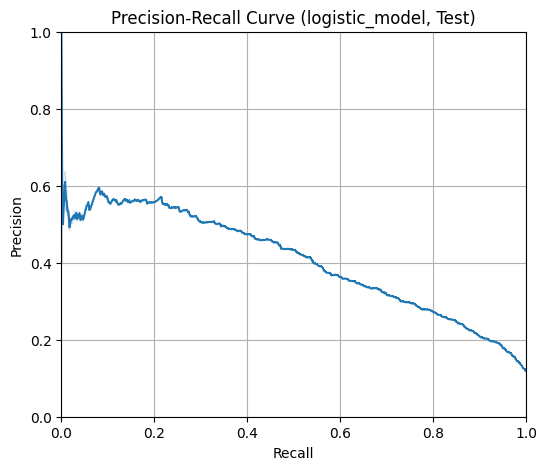

[Epoch 1] Train Loss=0.3299, Valid Loss=0.2975, Valid AUROC=0.8019, AUPRC=0.3638


[Epoch 2] Train Loss=0.3040, Valid Loss=0.2913, Valid AUROC=0.8144, AUPRC=0.3837


[Epoch 3] Train Loss=0.2990, Valid Loss=0.2900, Valid AUROC=0.8183, AUPRC=0.3831


[Epoch 4] Train Loss=0.2971, Valid Loss=0.2875, Valid AUROC=0.8206, AUPRC=0.3883


[Epoch 5] Train Loss=0.2934, Valid Loss=0.2901, Valid AUROC=0.8217, AUPRC=0.3873


...

[Epoch 8] Train Loss=0.2934, Valid Loss=0.2862, Valid AUROC=0.8227, AUPRC=0.3916


[Epoch 9] Train Loss=0.2930, Valid Loss=0.2866, Valid AUROC=0.8230, AUPRC=0.3923


[Epoch 10] Train Loss=0.2923, Valid Loss=0.2868, Valid AUROC=0.8233, AUPRC=0.3928


[Epoch 11] Train Loss=0.2916, Valid Loss=0.2862, Valid AUROC=0.8231, AUPRC=0.3913


[Epoch 12] Train Loss=0.2917, Valid Loss=0.2863, Valid AUROC=0.8232, AUPRC=0.3912
Early stopping triggered.

=== Test Metrics (MLP) ===
AUROC: 0.8254
AUPRC: 0.4003
Precision: 0.5673
Recall: 0.1149
F1: 0.1911
Accuracy: 0.8849
Brier: 0.0851
Precision@Recall_0.8: 0.2664


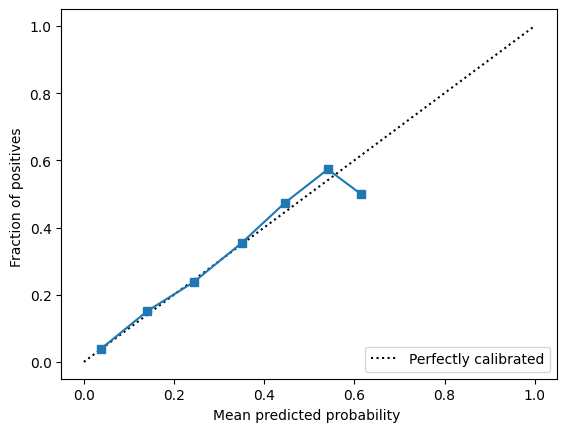

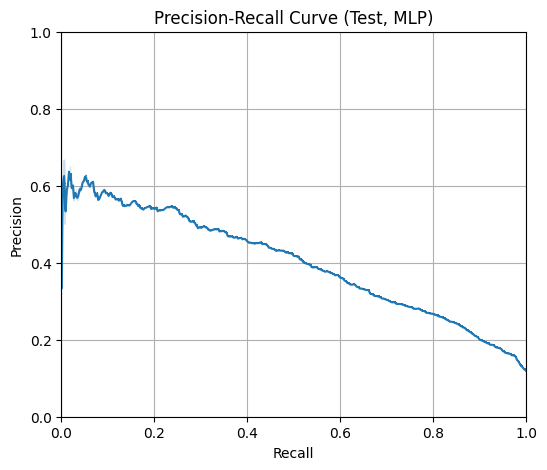

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:02:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best Validation AUPRC: 0.3872

Test Metrics for the Best Model:
AUROC: 0.8574
AUPRC: 0.3992
Precision: 0.5645
Recall: 0.1949
F1: 0.2897
Accuracy: 0.9191
Brier: 0.0617
Precision@Recall_0.8: 0.2368


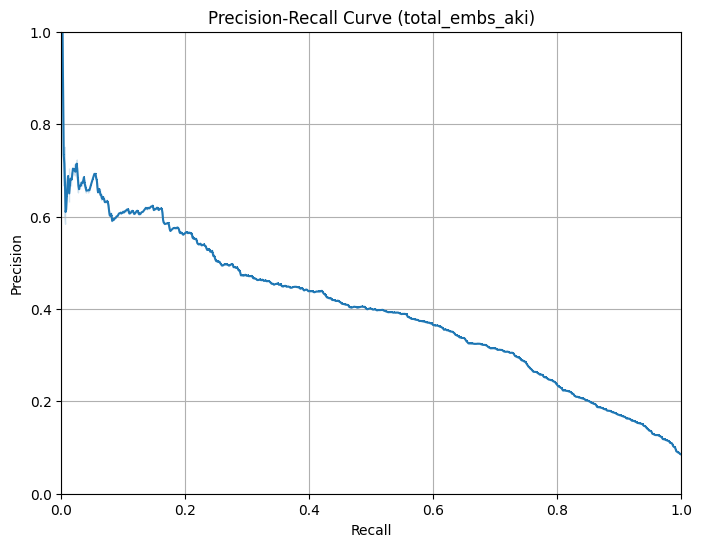

Model saved to ./saved_models



Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Validation AUPRC: 0.3055

Test Metrics for the Best Model:
AUROC: 0.8137
AUPRC: 0.3244
Precision: 0.5541
Recall: 0.0861
F1: 0.1490
Accuracy: 0.9167
Brier: 0.0665
Precision@Recall_0.8: 0.1848


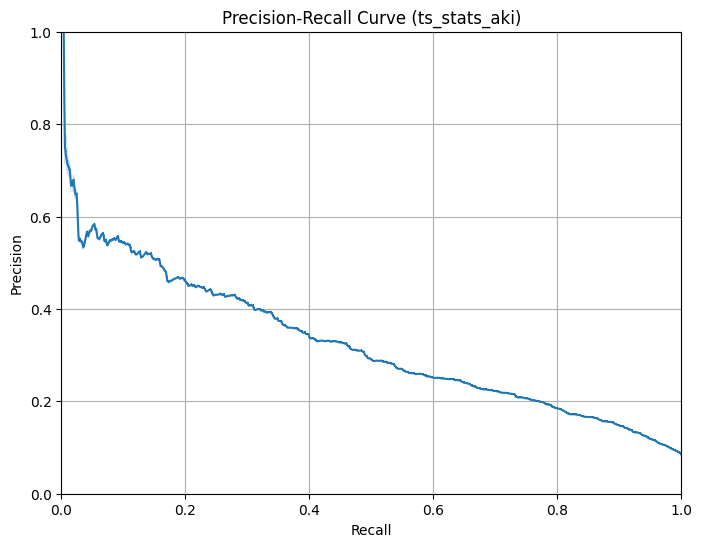

Model saved to ./saved_models



Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best Validation AUPRC: 0.3970

Test Metrics for the Best Model:
AUROC: 0.8237
AUPRC: 0.3934
Precision: 0.5464
Recall: 0.1884
F1: 0.2802
Accuracy: 0.8855
Brier: 0.0854
Precision@Recall_0.8: 0.2541


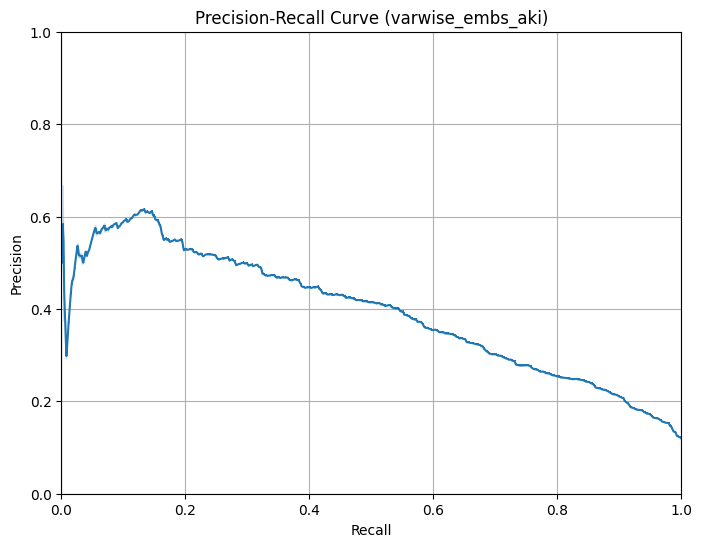

Model saved to ./saved_models

Comparison of Metrics:
Representation Logi: {'AUROC': 0.8315917207431315, 'AUPRC': 0.40564651564217713, 'Precision': 0.5577557755775577, 'Recall': 0.20023696682464456, 'F1': 0.2946817785527463, 'Accuracy': 0.8865834852095892, 'Brier': 0.08442881028043087, 'Precision@Recall_0.8': 0.2720321931589537}
Representation MLP: {'AUROC': 0.8254090682670939, 'AUPRC': 0.40030633404558563, 'Precision': 0.5672514619883041, 'Recall': 0.11492890995260663, 'F1': 0.19113300492610838, 'Accuracy': 0.884901163605776, 'Brier': 0.08509012092235975, 'Precision@Recall_0.8': 0.26635145784081954}
Representation 1: {'AUROC': 0.8573977788977181, 'AUPRC': 0.39915809567152466, 'Precision': 0.5644699140401146, 'Recall': 0.19485657764589515, 'F1': 0.2897058823529412, 'Accuracy': 0.9190887008962224, 'Brier': 0.061655592671890254, 'Precision@Recall_0.8': 0.23682669789227168}
Representation 2: {'AUROC': 0.8137440026473072, 'AUPRC': 0.32439853673252894, 'Precision': 0.554140127388535, 'Recal

In [15]:
train_vars_df = train_vars_df.drop(columns=var_categories['static'])
valid_vars_df = valid_vars_df.drop(columns=var_categories['static'])
test_vars_df  = test_vars_df.drop(columns=var_categories['static'])

train_vars_df_mimic = train_vars_df_mimic.drop(columns=var_categories['static'])
valid_vars_df_mimic = valid_vars_df_mimic.drop(columns=var_categories['static'])
test_vars_df_mimic  = test_vars_df_mimic.drop(columns=var_categories['static'])

pop_static = var_categories.pop('static', None)

model_logi, metrics_logi = grid_search_train_and_evaluate_logistic(    
    train_vars_df,
    valid_vars_df,
    test_vars_df)

# (1) 2-layer MLP 학습
model_mlp, metrics_mlp = train_validate_mlp(
    train_vars_df,
    valid_vars_df,
    test_vars_df,
    train_vars_df.shape[1]-1,
    hidden_dim=64,
    lr=1e-3,
    batch_size=64,
    epochs=30,
    patience=5,
    save_path='./best_mlp.pt',
    verbose=True
)

# Evaluate downstream model on REP_1
model_1, params_1, auprc_1, metrics_1 = grid_search_train_and_evaluate_downstream_model(
    train_emb_df,
    valid_emb_df,
    test_emb_df,
    param_grid,
    model_name='total_embs_aki',
    save_path='./saved_models',
    verbose=False
)

# On REP_2 . . .
model_2, params_2, auprc_2, metrics_2 = grid_search_train_and_evaluate_downstream_model(
    train_df_eicu,
    valid_df_eicu,
    test_df_eicu,
    param_grid,
    model_name='ts_stats_aki',
    save_path='./saved_models',
    verbose=False
)

model_3, params_3, auprc_3, metrics_3 = grid_search_train_and_evaluate_downstream_model(
    train_vars_df,
    valid_vars_df,
    test_vars_df,
    param_grid,
    model_name='varwise_embs_aki',
    save_path='./saved_models',
    verbose=False
)

# Compare metrics...
print("\nComparison of Metrics:")
print("Representation Logi:", metrics_logi)
print("Representation MLP:", metrics_mlp)
print("Representation 1:", metrics_1)
print("Representation 2:", metrics_2)
print("Representation 3:", metrics_3)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

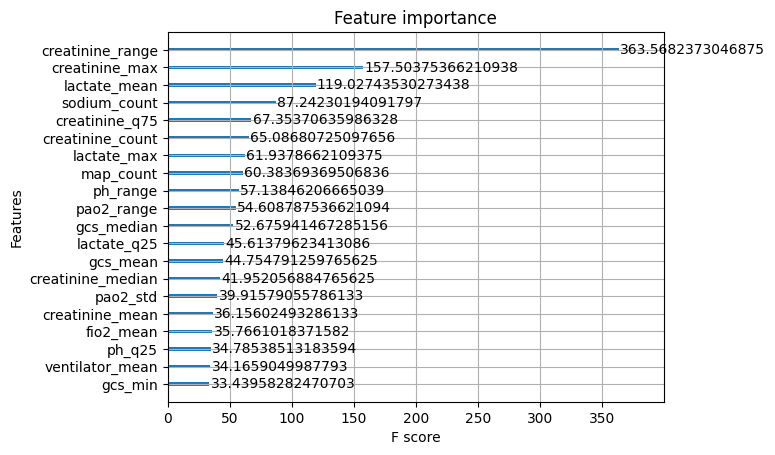

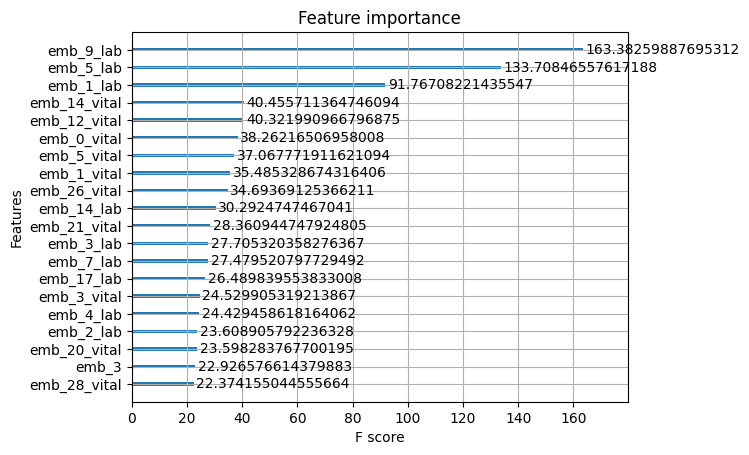

In [16]:
xgb.plot_importance(model_2.get_booster(), importance_type='gain', max_num_features=20)
xgb.plot_importance(model_3.get_booster(), importance_type='gain', max_num_features=20)

In [17]:
# # Version 4: treat 변수 제외
# train_vars_no_treat = train_vars_df.drop(columns=var_categories['treat'])
# valid_vars_no_treat = valid_vars_df.drop(columns=var_categories['treat'])
# test_vars_no_treat  = test_vars_df.drop(columns=var_categories['treat'])

# model_v4, params_v4, auprc_v4, metrics_v4 = grid_search_train_and_evaluate_downstream_model(
#     train_vars_no_treat,
#     valid_vars_no_treat,
#     test_vars_no_treat,
#     param_grid,
#     model_name='varwise_embs_aki_no_treat',
#     save_path='./saved_models',
#     verbose=False
# )

# # Version 5: lab 변수 제외
# train_vars_no_lab = train_vars_df.drop(columns=var_categories['lab'])
# valid_vars_no_lab = valid_vars_df.drop(columns=var_categories['lab'])
# test_vars_no_lab  = test_vars_df.drop(columns=var_categories['lab'])

# model_v5, params_v5, auprc_v5, metrics_v5 = grid_search_train_and_evaluate_downstream_model(
#     train_vars_no_lab,
#     valid_vars_no_lab,
#     test_vars_no_lab,
#     param_grid,
#     model_name='varwise_embs_aki_no_lab',
#     save_path='./saved_models',
#     verbose=False
# )

# # Version 6: lab와 treat 모두 제외
# cols_to_drop = var_categories['lab'] + var_categories['treat']
# train_vars_no_lt = train_vars_df.drop(columns=cols_to_drop)
# valid_vars_no_lt = valid_vars_df.drop(columns=cols_to_drop)
# test_vars_no_lt  = test_vars_df.drop(columns=cols_to_drop)

# model_v6, params_v6, auprc_v6, metrics_v6 = grid_search_train_and_evaluate_downstream_model(
#     train_vars_no_lt,
#     valid_vars_no_lt,
#     test_vars_no_lt,
#     param_grid,
#     model_name='varwise_embs_aki_no_lab_no_treat',
#     save_path='./saved_models',
#     verbose=False
# )

# # Version 7: vital 제외
# cols_to_drop = var_categories['vital']
# train_vars_no_vital = train_vars_df.drop(columns=cols_to_drop)
# valid_vars_no_vital = valid_vars_df.drop(columns=cols_to_drop)
# test_vars_no_vital  = test_vars_df.drop(columns=cols_to_drop)

# model_v7, params_v7, auprc_v7, metrics_v7 = grid_search_train_and_evaluate_downstream_model(
#     train_vars_no_vital,
#     valid_vars_no_vital,
#     test_vars_no_vital,
#     param_grid,
#     model_name='varwise_embs_aki_no_vital',
#     save_path='./saved_models',
#     verbose=False
# )

# # 결과 출력 (예시)
# print("=== Version 4 (no treat) ===")
# print(metrics_v4)
# print("=== Version 5 (no lab) ===")
# print(metrics_v5)
# print("=== Version 6 (no lab & no treat) ===")
# print(metrics_v6)
# print("=== Version 7 (no vital) ===")
# print(metrics_v7)


Test Metrics for model_3:
AUROC: 0.8199
AUPRC: 0.5227
Precision: 0.6872
Recall: 0.2350
F1: 0.3502
Accuracy: 0.8453
Brier: 0.1132
Precision@Recall_0.8: 0.3511


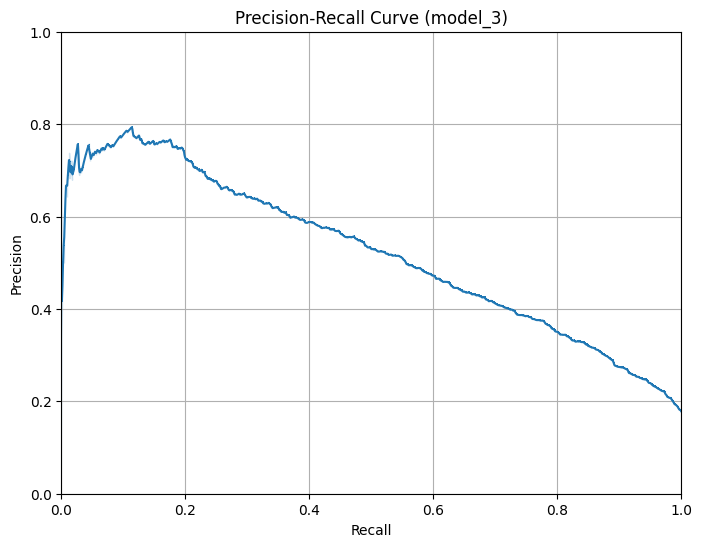

In [18]:
# test_vars_df_mimic의 'outcome' 열은 label, 나머지는 feature로 사용
X_test = test_vars_df_mimic.drop(columns=['outcome'])
y_test = test_vars_df_mimic['outcome']

# model_3로 예측 수행 (model_3는 sklearn wrapper를 사용하는 XGB 모델)
y_pred_proba = model_3.predict_proba(X_test)[:, 1]
y_pred = model_3.predict(X_test)

# 평가 지표 계산
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
accuracy_val = accuracy_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred_proba)

# 특정 recall (0.8) 이상인 구간에서의 최대 precision 계산
target_recall = 0.8
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
if np.any(recalls >= target_recall):
    precision_at_target = np.max(precisions[recalls >= target_recall])
else:
    precision_at_target = np.nan

test_metrics = {
    'AUROC': auroc,
    'AUPRC': auprc,
    'Precision': precision_val,
    'Recall': recall_val,
    'F1': f1_val,
    'Accuracy': accuracy_val,
    'Brier': brier,
    'Precision@Recall_0.8': precision_at_target
}

print("\nTest Metrics for model_3:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Precision-Recall Curve 그리기 (x, y축 범위를 0~1로 고정)
plt.figure(figsize=(8,6))
sns.lineplot(x=recalls, y=precisions, marker=',')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (model_3)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

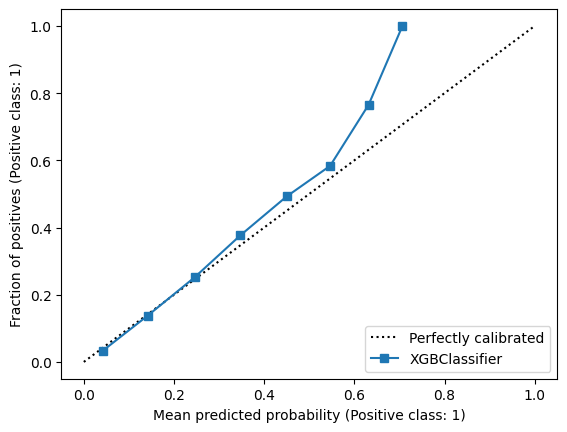

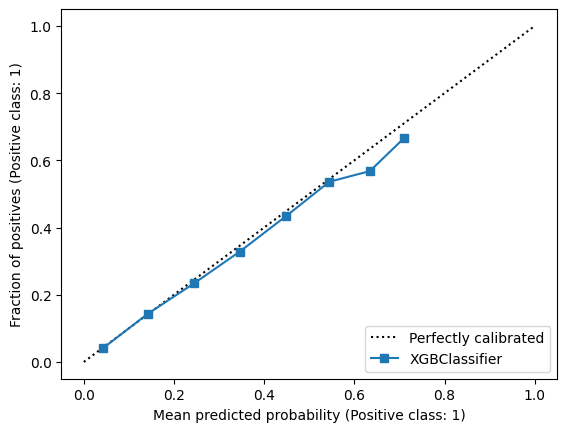

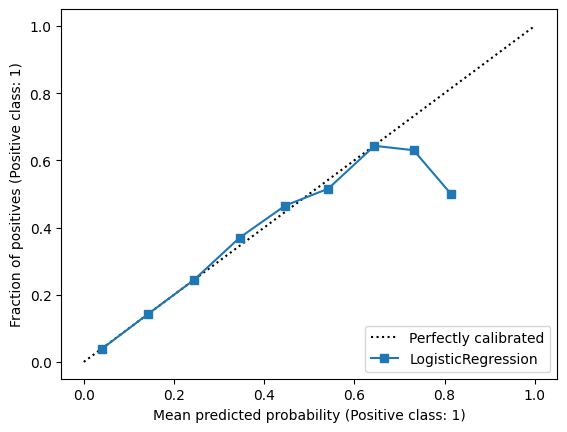

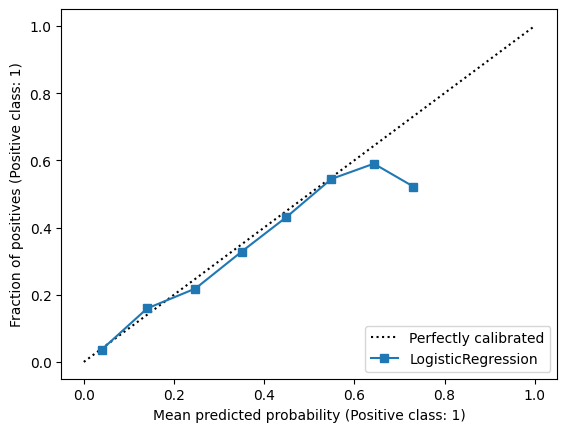

In [19]:
X_test = test_vars_df.drop(columns=['outcome'])
y_test = test_vars_df['outcome']
X_train = train_vars_df.drop(columns=['outcome'])
y_train = train_vars_df['outcome']
disp = CalibrationDisplay.from_estimator(model_3, X_train, y_train, n_bins=10)
disp = CalibrationDisplay.from_estimator(model_3, X_test, y_test, n_bins=10)

disp = CalibrationDisplay.from_estimator(model_logi, X_train, y_train, n_bins=10)
disp = CalibrationDisplay.from_estimator(model_logi, X_test, y_test, n_bins=10)


Test Metrics for model_3:
AUROC: 0.8189
AUPRC: 0.3988
Precision: 0.5296
Recall: 0.1908
F1: 0.2805
Accuracy: 0.8842
Brier: 0.0871
Precision@Recall_0.8: 0.2552


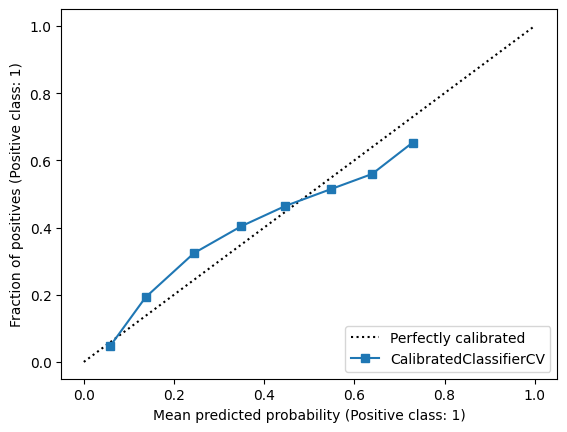

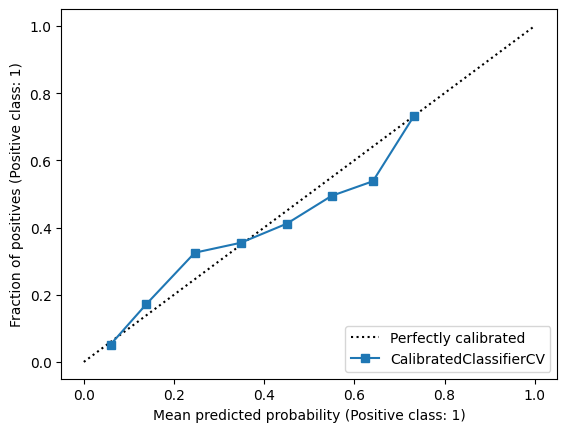

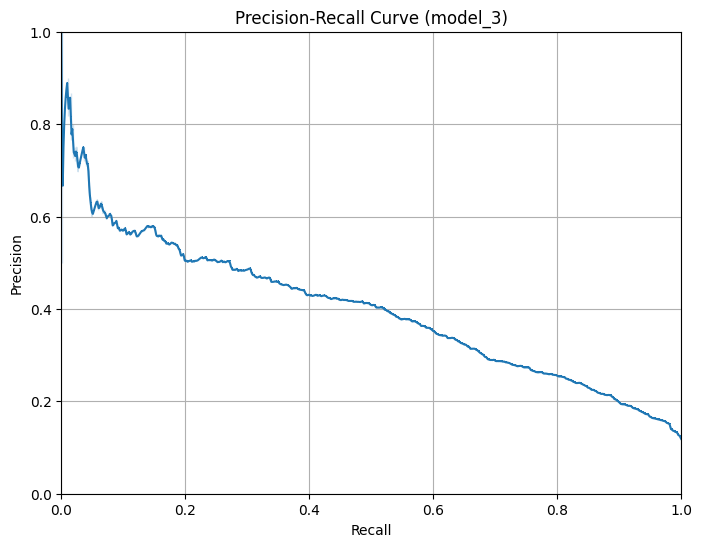

In [20]:
# Use valid_vars to calibrate XGB
X_train = train_vars_df.drop(columns=['outcome'])
y_train = train_vars_df['outcome']

X_valid = valid_vars_df.drop(columns=['outcome'])
y_valid = valid_vars_df['outcome']

X_test = test_vars_df.drop(columns=['outcome'])
y_test = test_vars_df['outcome']

model_calib = CalibratedClassifierCV(estimator=model_3, method='sigmoid', cv=5)
model_calib.fit(X_valid, y_valid)

y_pred_proba = model_calib.predict_proba(X_test)[:, 1]
y_pred = model_calib.predict(X_test)

disp = CalibrationDisplay.from_estimator(model_calib, X_train, y_train, n_bins=10)
disp = CalibrationDisplay.from_estimator(model_calib, X_test, y_test, n_bins=10)

# 평가 지표 계산
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
accuracy_val = accuracy_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred_proba)

# 특정 recall (0.8) 이상인 구간에서의 최대 precision 계산
target_recall = 0.8
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
if np.any(recalls >= target_recall):
    precision_at_target = np.max(precisions[recalls >= target_recall])
else:
    precision_at_target = np.nan

test_metrics = {
    'AUROC': auroc,
    'AUPRC': auprc,
    'Precision': precision_val,
    'Recall': recall_val,
    'F1': f1_val,
    'Accuracy': accuracy_val,
    'Brier': brier,
    'Precision@Recall_0.8': precision_at_target
}

print("\nTest Metrics for model_3:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Precision-Recall Curve 그리기 (x, y축 범위를 0~1로 고정)
plt.figure(figsize=(8,6))
sns.lineplot(x=recalls, y=precisions, marker=',')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (model_3)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mode


Test Metrics for Logistic:
AUROC: 0.8230
AUPRC: 0.3914
Precision: 0.5388
Recall: 0.1564
F1: 0.2424
Accuracy: 0.8843
Brier: 0.0859
Precision@Recall_0.8: 0.2621


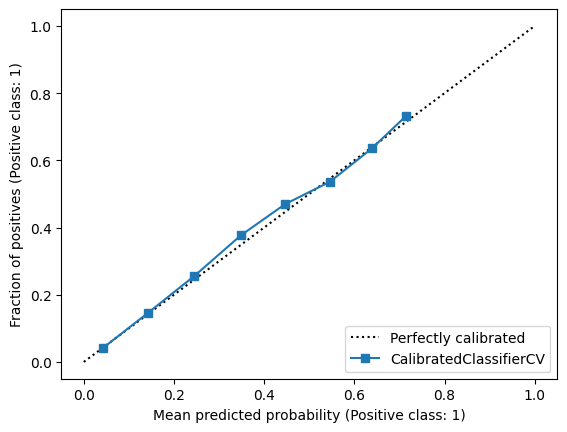

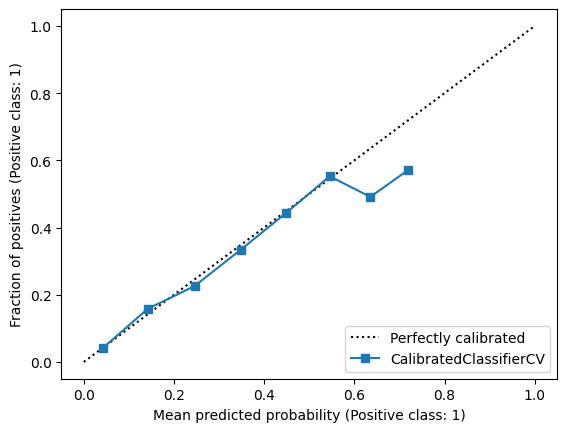

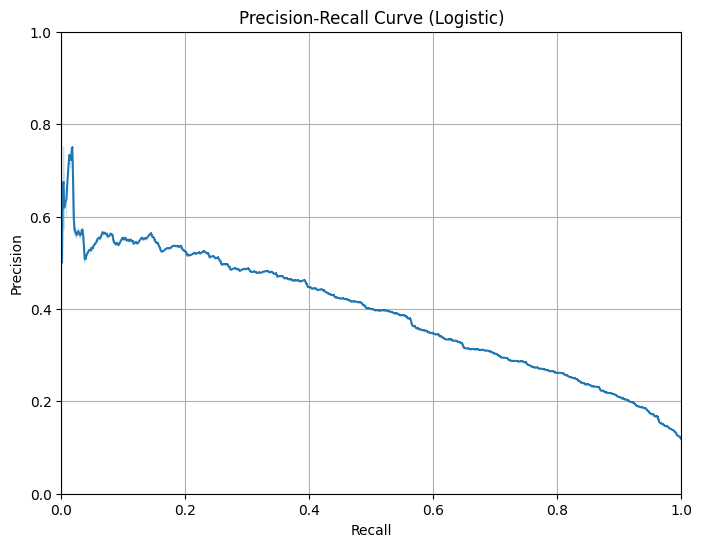

In [21]:
# Use valid_vars to calibrate LOGI
X_train = train_vars_df.drop(columns=['outcome'])
y_train = train_vars_df['outcome']

X_valid = valid_vars_df.drop(columns=['outcome'])
y_valid = valid_vars_df['outcome']

X_test = test_vars_df.drop(columns=['outcome'])
y_test = test_vars_df['outcome']

model_logi_calib = CalibratedClassifierCV(estimator=model_logi, method='sigmoid', cv=5)
model_logi_calib.fit(X_valid, y_valid)

y_pred_proba = model_logi_calib.predict_proba(X_test)[:, 1]
y_pred = model_logi_calib.predict(X_test)

disp = CalibrationDisplay.from_estimator(model_logi_calib, X_train, y_train, n_bins=10)
disp = CalibrationDisplay.from_estimator(model_logi_calib, X_test, y_test, n_bins=10)

# 평가 지표 계산
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
accuracy_val = accuracy_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred_proba)

# 특정 recall (0.8) 이상인 구간에서의 최대 precision 계산
target_recall = 0.8
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
if np.any(recalls >= target_recall):
    precision_at_target = np.max(precisions[recalls >= target_recall])
else:
    precision_at_target = np.nan

test_metrics = {
    'AUROC': auroc,
    'AUPRC': auprc,
    'Precision': precision_val,
    'Recall': recall_val,
    'F1': f1_val,
    'Accuracy': accuracy_val,
    'Brier': brier,
    'Precision@Recall_0.8': precision_at_target
}

print("\nTest Metrics for Logistic:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Precision-Recall Curve 그리기 (x, y축 범위를 0~1로 고정)
plt.figure(figsize=(8,6))
sns.lineplot(x=recalls, y=precisions, marker=',')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Logistic)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Explain

In [22]:

# define the causal graph
GRAPH = Graph(
    nodes= list(var_categories.keys()),
    edges=[
        # ('static', 'vital'),
        # ('static', 'lab'),
        ('vital', 'treat'),
        ('lab', 'treat'),
        # ('static', 'treat'),
        # ('static', 'outcome'),
        ('vital', 'outcome'), 
        ('lab', 'outcome'), 
        ('treat', 'outcome'), 
    ]
)

train_features = var_categories['lab'] + var_categories['treat'] + var_categories['vital']


In [23]:
def auprc(model, data, subset_cols=None, weight=None, target_name='outcome'):
    """
    모델의 예측 확률을 사용해 AUPRC (Average Precision Score)를 계산하는 함수.

    Parameters:
      - model: 예측 모델 (predict_proba 메서드가 있어야 함)
      - data: 평가할 DataFrame
      - subset_cols: 사용할 feature 컬럼 리스트 (None이면 전체 데이터 사용)
      - weight: 샘플 가중치 (None이면 가중치 없이 계산)
      - target_name: 타겟 컬럼 이름 (기본값 'Y')

    Returns:
      - AUPRC 값 (float)
    """
    data_input = data[subset_cols] if subset_cols is not None else data
    return average_precision_score(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight=weight)

def brier(model, data, subset_cols = None, weight = None, target_name = 'outcome'):
    data_input = data[subset_cols] if subset_cols is not None else data
    return brier_score_loss(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight = weight)

def auprc_torch(model, data: pd.DataFrame, subset_cols=None, weight=None, target_name='outcome'):
    # (1) 사용할 feature/target 분리
    if subset_cols is not None:
        df_feats = data[subset_cols]
    else:
        # default: 모든 열 중 outcome 열만 제외
        df_feats = data.drop(columns=[target_name])
    y_true = data[target_name].values

    # (2) Pandas → NumPy → torch.Tensor
    #     (float 타입으로 변환, 기기의 일치)
    X_np = df_feats.to_numpy(dtype=np.float32)
    X_tensor = torch.from_numpy(X_np)

    # 모델이 이미 특정 디바이스에 올라가 있을 수 있으므로, 일치시켜줍니다.
    device = next(model.parameters()).device
    X_tensor = X_tensor.to(device)

    # (3) 모델 예측 (no_grad 상태, eval 모드)
    model.eval()
    with torch.no_grad():
        output = model(X_tensor)
        probs = torch.sigmoid(output).cpu().numpy().reshape(-1)

    # (4) AUPRC 계산 (scikit-learn)
    return average_precision_score(y_true, probs, sample_weight=weight)


def brier_torch(model, data: pd.DataFrame, subset_cols=None, weight=None, target_name='outcome'):

    # (1) feature/target 분리
    if subset_cols is not None:
        df_feats = data[subset_cols]
    else:
        df_feats = data.drop(columns=[target_name])
    y_true = data[target_name].values

    # (2) Pandas → NumPy → torch.Tensor
    X_np = df_feats.to_numpy(dtype=np.float32)
    X_tensor = torch.from_numpy(X_np)
    device = next(model.parameters()).device
    X_tensor = X_tensor.to(device)

    # (3) 모델 예측 (no_grad, eval)
    model.eval()
    with torch.no_grad():
        output = model(X_tensor)
        probs = torch.sigmoid(output).cpu().numpy().reshape(-1)

    # (4) Brier Score 계산 (scikit-learn)
    return brier_score_loss(y_true, probs, sample_weight=weight)

In [24]:
train_features = ['emb_0_vital', 'emb_1_vital', 'emb_2_vital', 'emb_3_vital', 'emb_4_vital', 'emb_5_vital',
                'emb_6_vital', 'emb_7_vital', 'emb_8_vital', 'emb_9_vital', 'emb_10_vital', 'emb_11_vital',
                'emb_12_vital', 'emb_13_vital', 'emb_14_vital', 'emb_15_vital', 'emb_16_vital', 'emb_17_vital',
                'emb_18_vital', 'emb_19_vital', 'emb_20_vital', 'emb_21_vital', 'emb_22_vital', 'emb_23_vital',
                'emb_24_vital', 'emb_25_vital', 'emb_26_vital', 'emb_27_vital', 'emb_28_vital', 'emb_29_vital',
                'emb_30_vital', 'emb_31_vital', 'emb_0_lab', 'emb_1_lab', 'emb_2_lab', 'emb_3_lab', 'emb_4_lab',
                'emb_5_lab', 'emb_6_lab', 'emb_7_lab', 'emb_8_lab', 'emb_9_lab', 'emb_10_lab', 'emb_11_lab', 
                'emb_12_lab', 'emb_13_lab', 'emb_14_lab', 'emb_15_lab', 'emb_16_lab', 'emb_17_lab', 'emb_18_lab', 
                'emb_19_lab', 'emb_20_lab', 'emb_21_lab', 'emb_22_lab', 'emb_23_lab', 'emb_24_lab', 'emb_25_lab', 
                'emb_26_lab', 'emb_27_lab', 'emb_28_lab', 'emb_29_lab', 'emb_30_lab', 'emb_31_lab', 'emb_0', 'emb_1', 
                'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 
                'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 
                'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 
                #'age', 'height', 'gender'
                ]

In [25]:
def explain_model(exp, model, auprc = auprc, brier = brier):
    print("==============")
    print("AUPRC")
    print("==============")
    exp.get_all_possible_shifts()

    perfs = exp.get_perf_on_sets(model, metric = auprc)
    print(perfs)

    res_auprc = exp.explain(model, metric = auprc)
    print(res_auprc)

    print("==============")
    print("Brier Score")
    print("==============")
    perfs = exp.get_perf_on_sets(model, metric = brier)
    print(perfs)

    res_brier = exp.explain(model, metric = brier)
    print(res_brier)

    print(exp.scale(res_brier, perfs))

AUPRC
{'source': 0.3934194437195952, 'target': 0.5227257512392434}


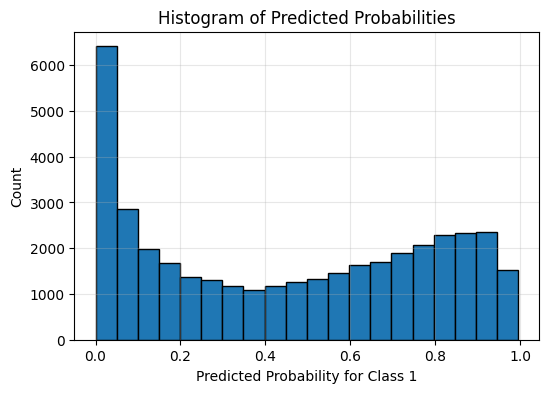

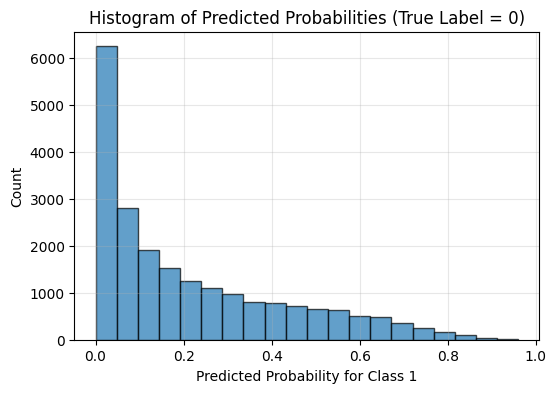

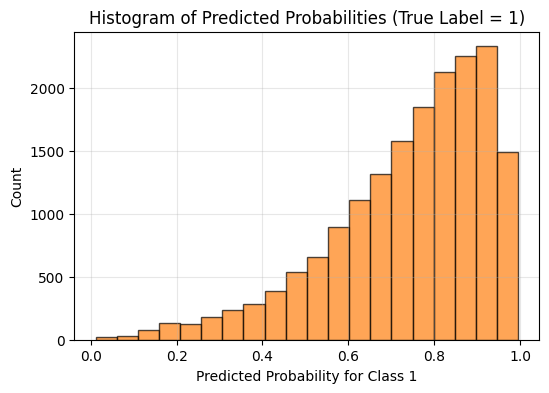

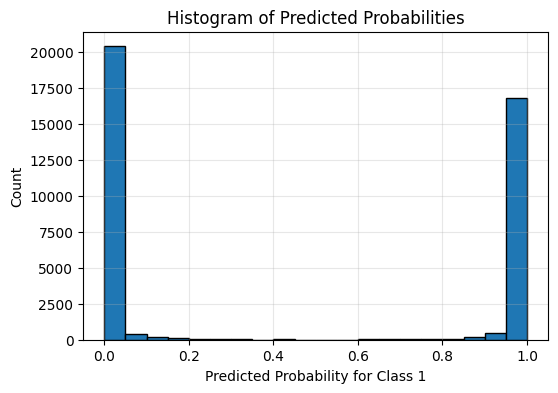

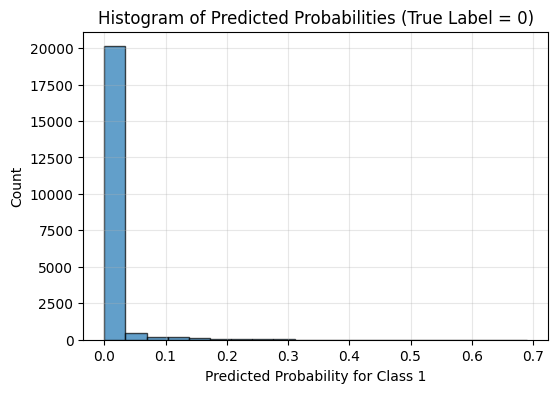

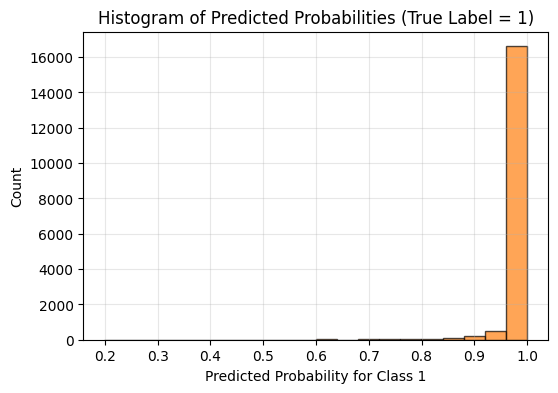

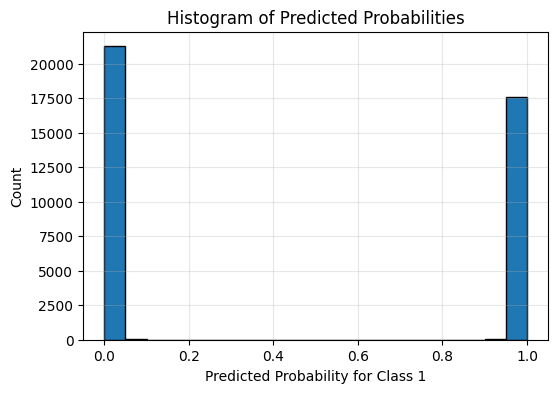

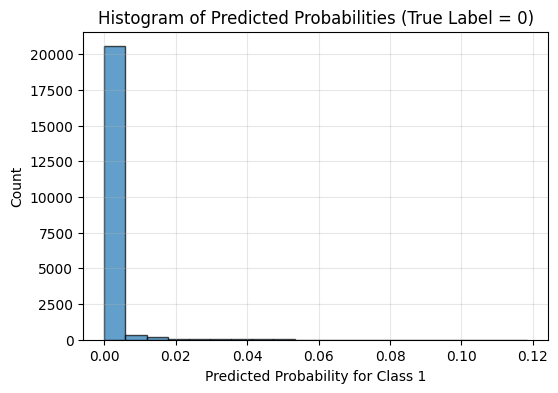

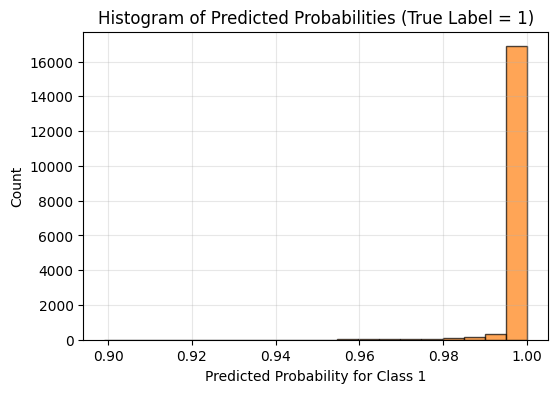

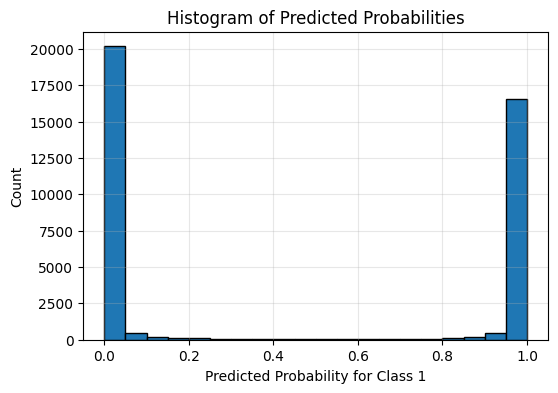

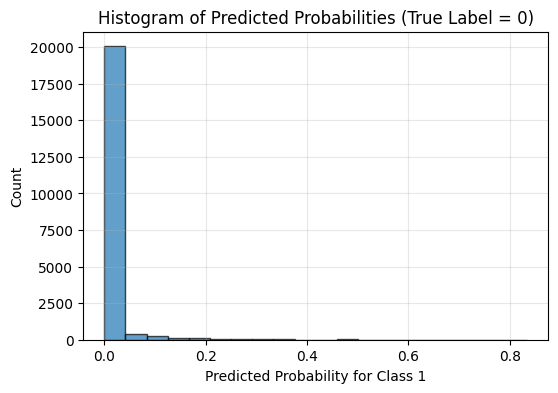

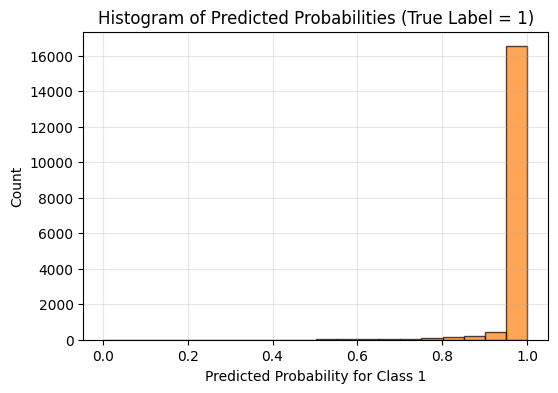

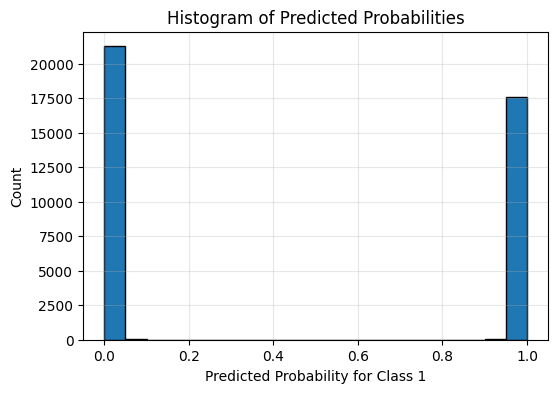

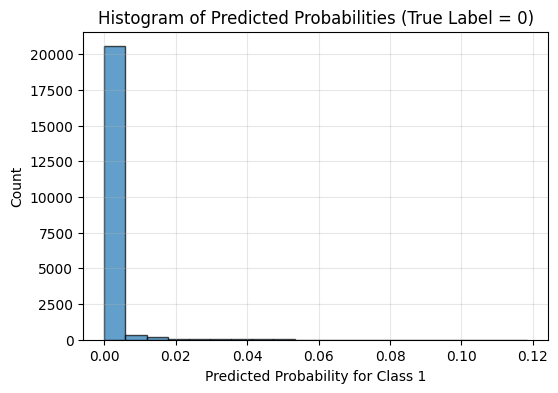

Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 212.66it/s]

P(lab)                         -0.024044
P(vital)                       -0.208655
P(treat | lab,vital)            0.193472
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08544608367996348, 'target': 0.11318559959882944}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 15335.66it/s]

...

Evaluate set function: 16it [00:00, 12122.27it/s]

P(lab)                          0.038074
P(vital)                       -0.047297
P(treat | lab,vital)            0.164940
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08509012105968207, 'target': 0.11497370417253965}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 15944.13it/s]

P(lab)                          0.013409
P(vital)                       -0.083546
P(treat | lab,vital)           -0.006086
P(outcome | lab,treat,vital)    0.000000
dtype: float64
P(lab)                         -0.005257
P(vital)                        0.032754
P(treat | lab,vital)            0.002386
P(outcome | lab,treat,vital)   -0.000000
dtype: float64


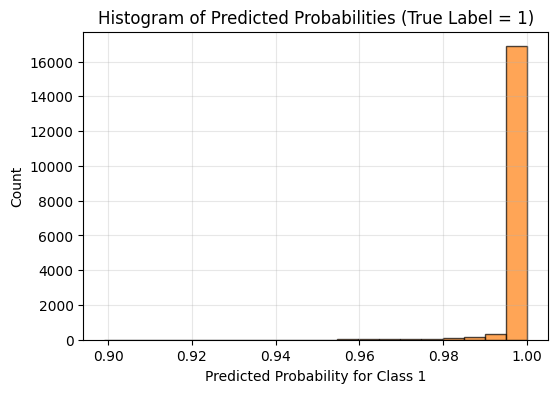

In [26]:
exp = CGExplainerDR(GRAPH, train_vars_df, test_vars_df, train_vars_df_mimic, test_vars_df_mimic,
        train_features, var_categories, target_name = 'outcome'
)
explain_model(exp, model_3)
explain_model(exp, model_calib)
explain_model(exp, model_logi)
explain_model(exp, model_logi_calib)
explain_model(exp, model_mlp, auprc_torch, brier_torch)

AUPRC
{'source': 0.3934194437195952, 'target': 0.5227257512392434}


c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


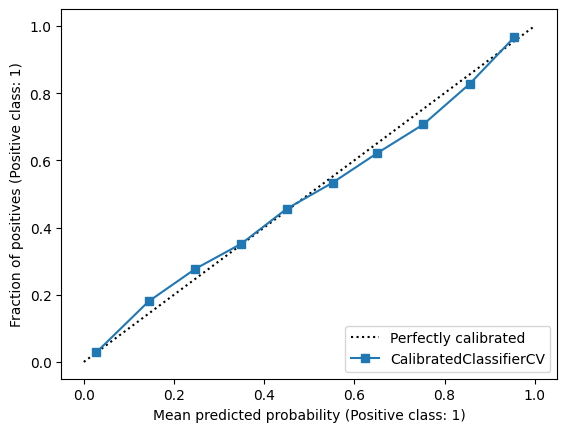

calibrating...


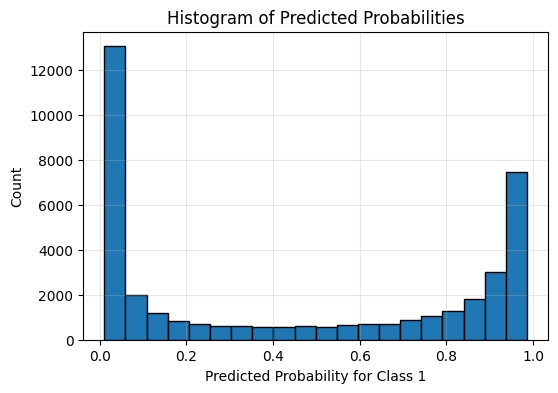

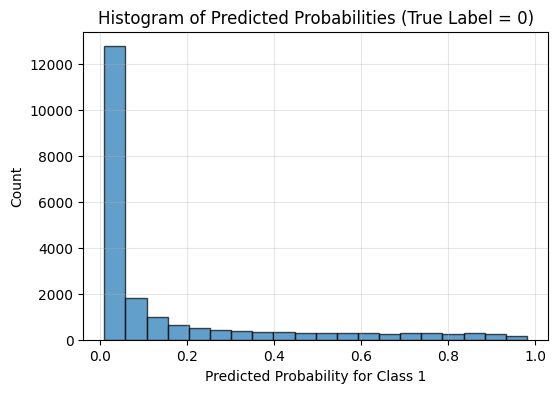

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


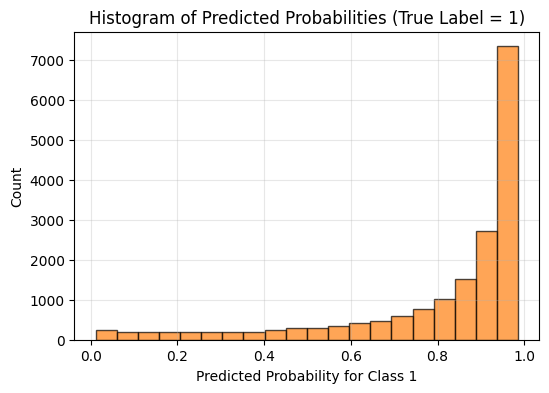

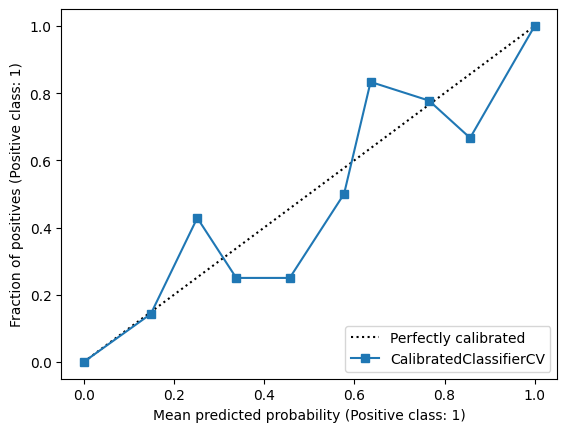

calibrating...


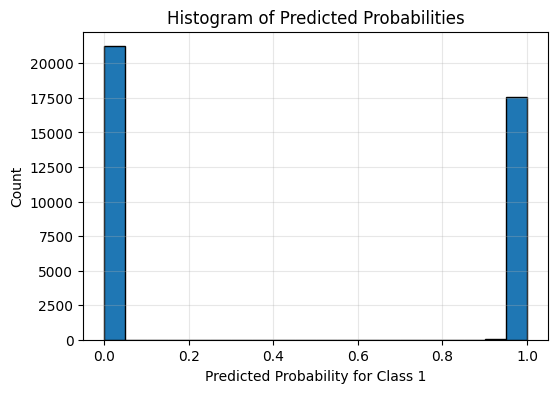

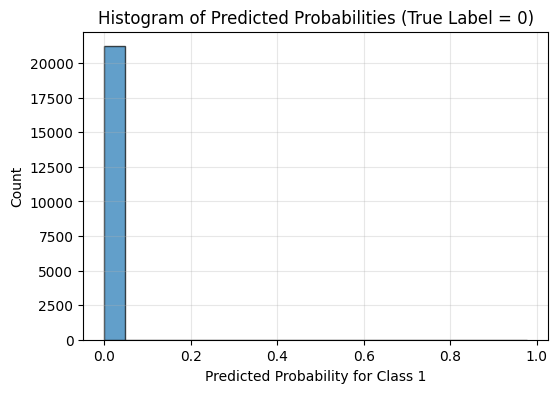

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


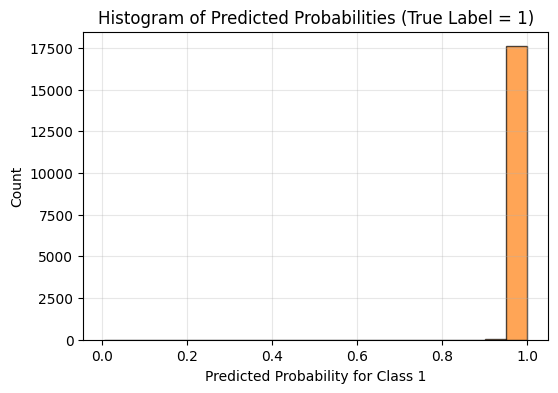

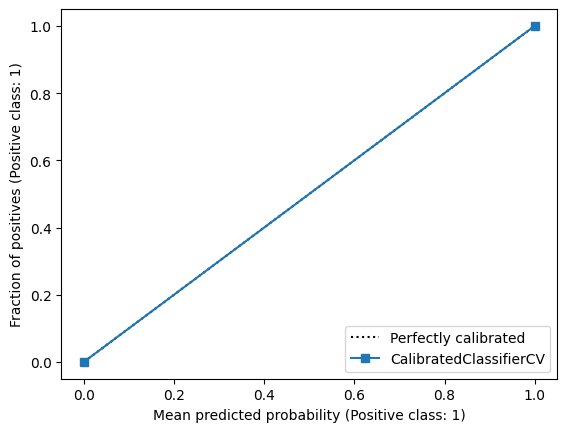

calibrating...


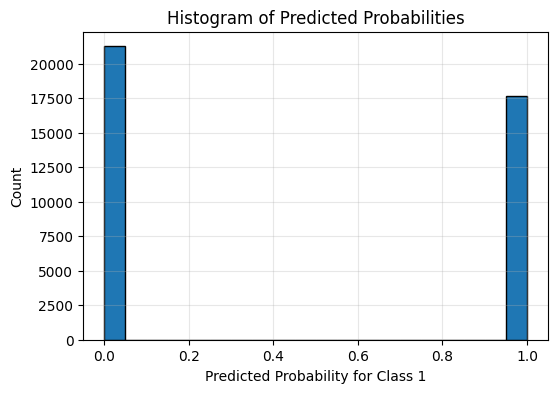

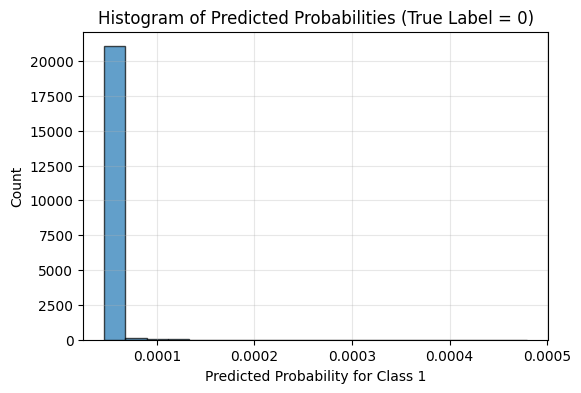

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


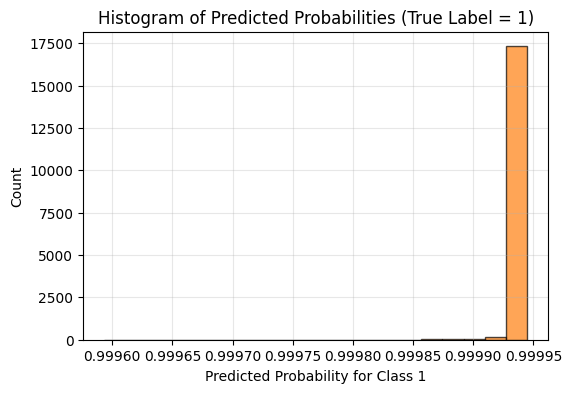

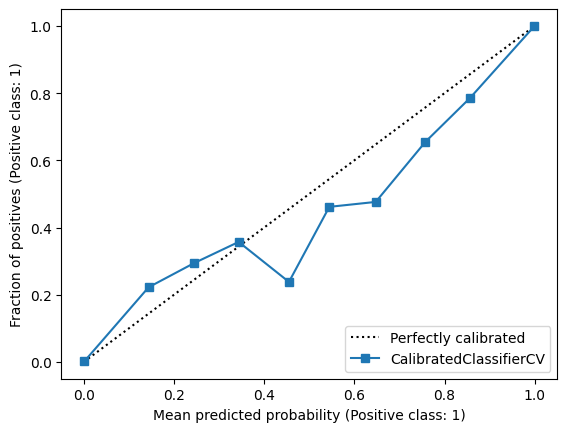

calibrating...


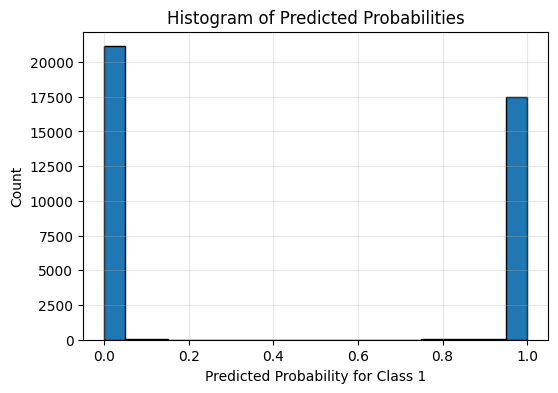

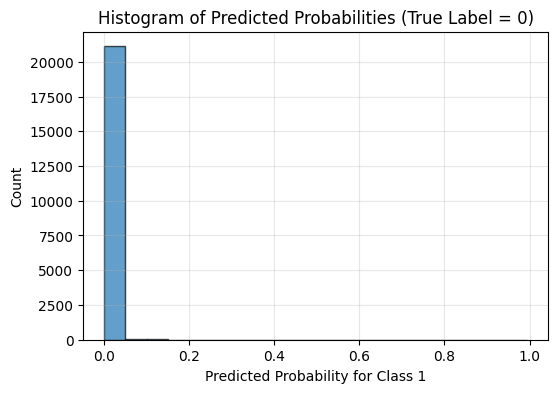

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


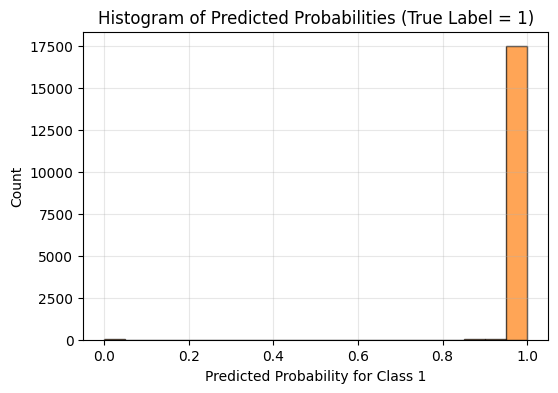

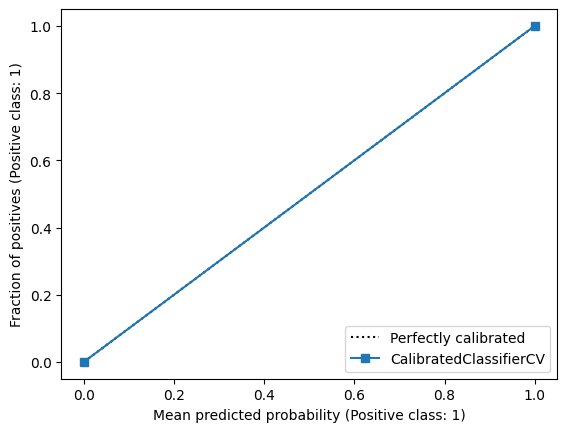

calibrating...


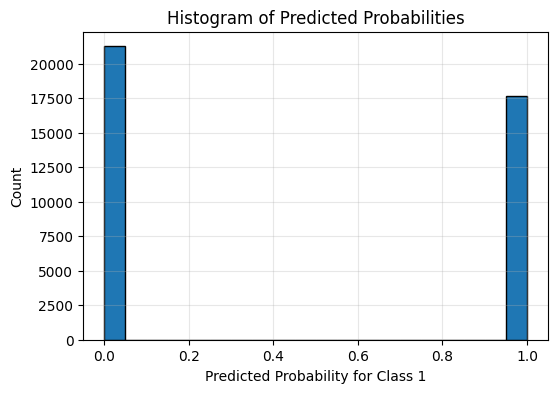

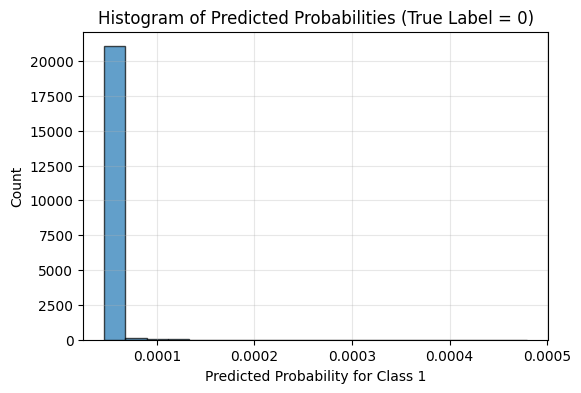

Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 16039.40it/s]

P(lab)                          0.103200
P(vital)                        0.003663
P(treat | lab,vital)            0.075297
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08544608367996348, 'target': 0.11318559959882944}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 16047.07it/s]

...

Evaluate set function: 16it [00:00, 12404.60it/s]

P(lab)                          0.043184
P(vital)                        0.095169
P(treat | lab,vital)           -0.126583
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08509012105968207, 'target': 0.11497370417253965}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 15974.50it/s]

P(lab)                          0.048860
P(vital)                       -0.060974
P(treat | lab,vital)           -0.027479
P(outcome | lab,treat,vital)    0.000000
dtype: float64
P(lab)                         -0.036879
P(vital)                        0.046022
P(treat | lab,vital)            0.020740
P(outcome | lab,treat,vital)   -0.000000
dtype: float64


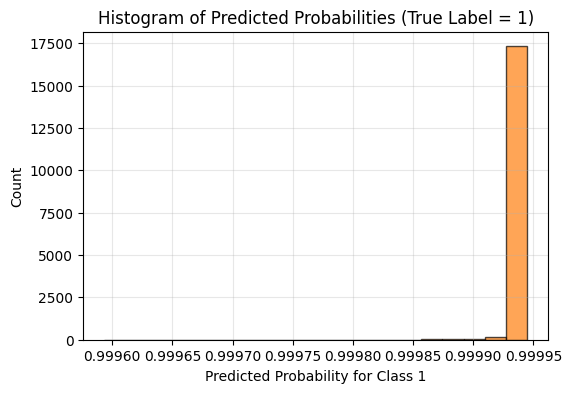

In [27]:
exp = CGExplainerDR(GRAPH, train_vars_df, test_vars_df, train_vars_df_mimic, test_vars_df_mimic,
        train_features, var_categories, target_name = 'outcome', clip_prob_thres=0.95, calibrate_weight_models=True
)
explain_model(exp, model_3)
explain_model(exp, model_calib)
explain_model(exp, model_logi)
explain_model(exp, model_logi_calib)
explain_model(exp, model_mlp, auprc_torch, brier_torch)

AUPRC
{'source': 0.3934194437195952, 'target': 0.5227257512392434}


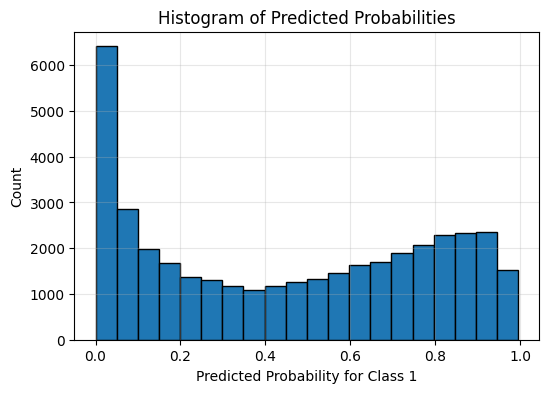

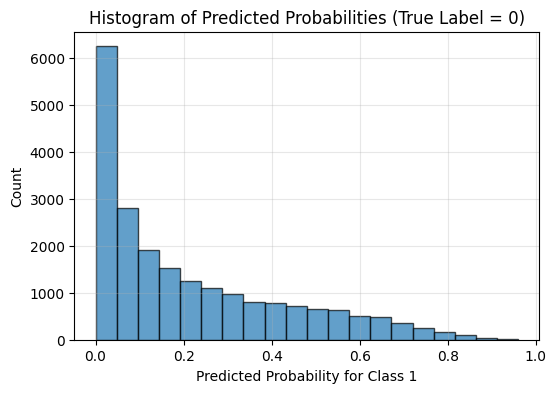

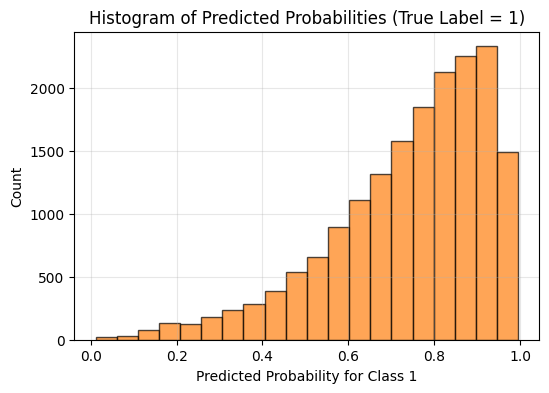

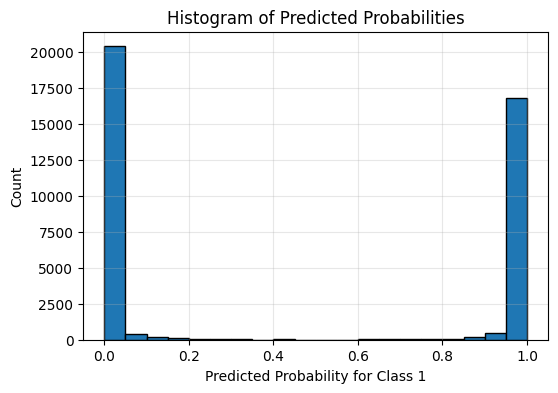

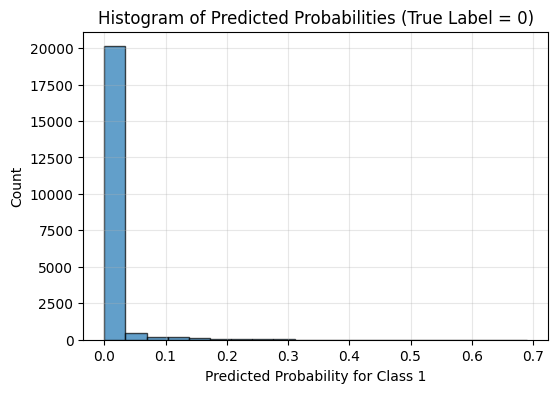

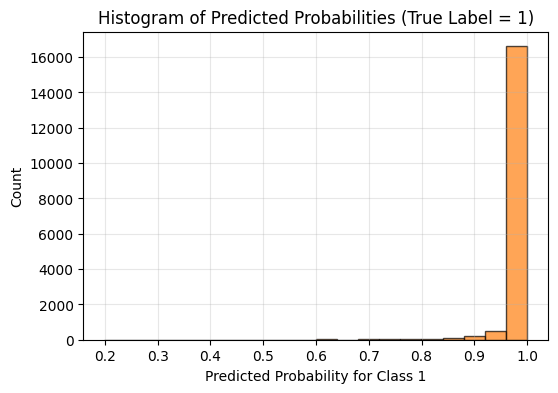

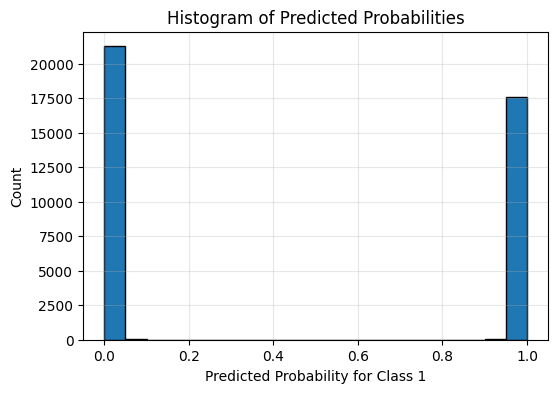

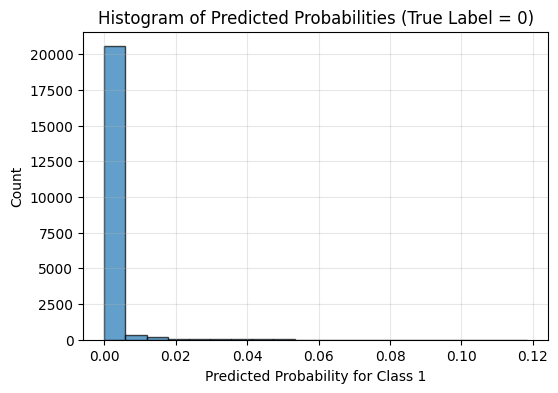

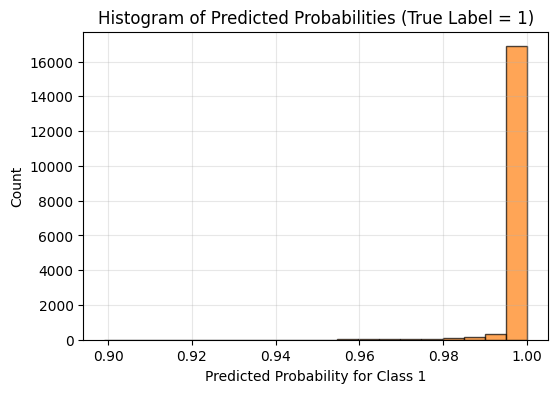

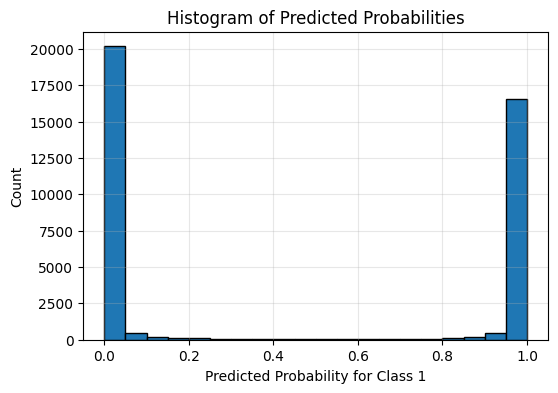

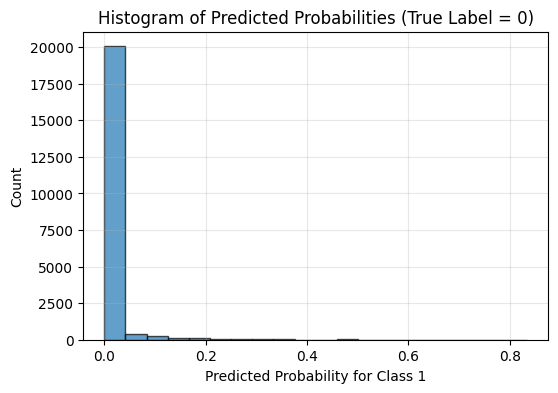

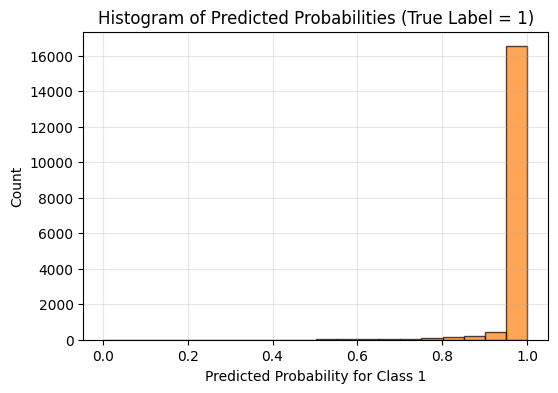

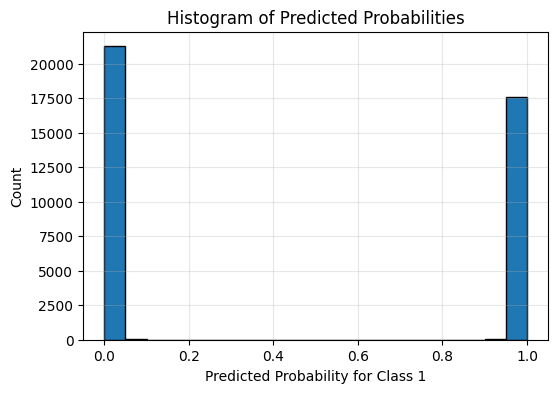

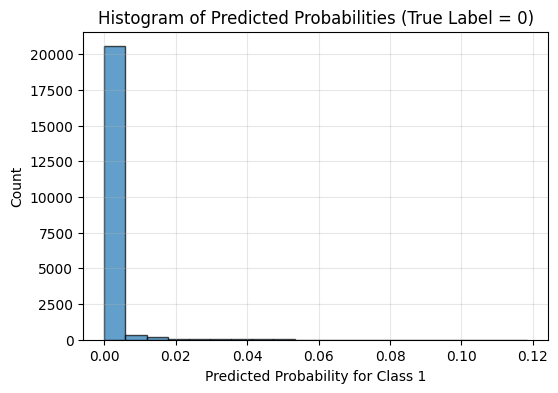

Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 16050.91it/s]

P(lab)                         -0.003451
P(vital)                       -0.032249
P(treat | lab,vital)           -0.076191
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08544608367996348, 'target': 0.11318559959882944}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 16047.07it/s]

...

Evaluate set function: 16it [00:00, 15248.55it/s]

P(lab)                          0.025775
P(vital)                        0.048414
P(treat | lab,vital)           -0.120981
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08509012105968207, 'target': 0.11497370417253965}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 11066.77it/s]

P(lab)                          0.017167
P(vital)                       -0.035240
P(treat | lab,vital)           -0.022958
P(outcome | lab,treat,vital)    0.000000
dtype: float64
P(lab)                         -0.012503
P(vital)                        0.025666
P(treat | lab,vital)            0.016721
P(outcome | lab,treat,vital)   -0.000000
dtype: float64


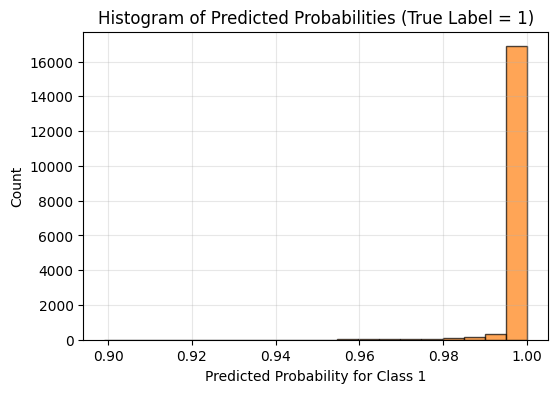

In [28]:
exp = CGExplainerDR(GRAPH, train_vars_df, test_vars_df, train_vars_df_mimic, test_vars_df_mimic,
        train_features, var_categories, target_name = 'outcome', clip_prob_thres=0.95
)
explain_model(exp, model_3)
explain_model(exp, model_calib)
explain_model(exp, model_logi)
explain_model(exp, model_logi_calib)
explain_model(exp, model_mlp, auprc_torch, brier_torch)

AUPRC
{'source': 0.3934194437195952, 'target': 0.5227257512392434}


c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


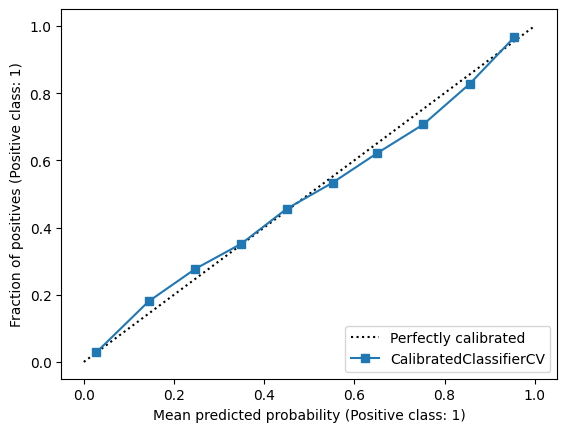

calibrating...


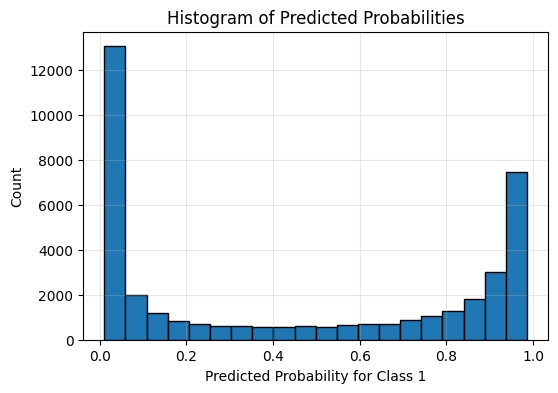

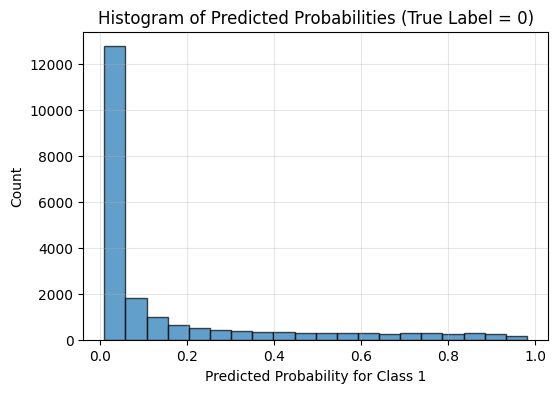

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


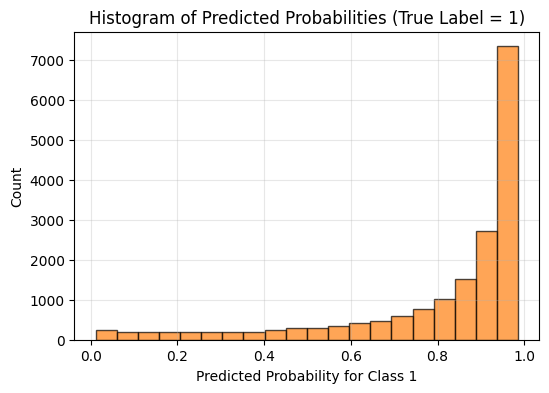

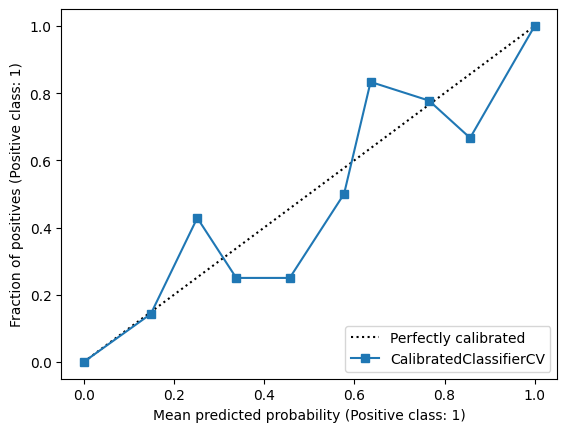

calibrating...


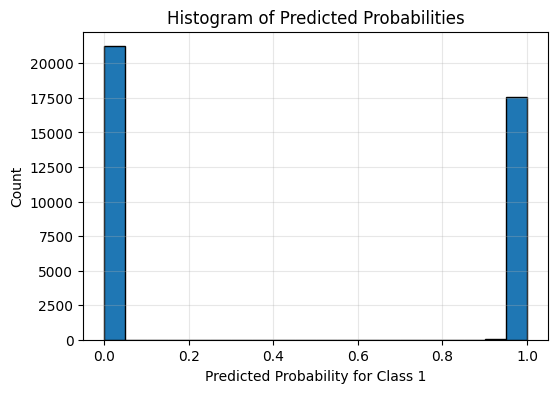

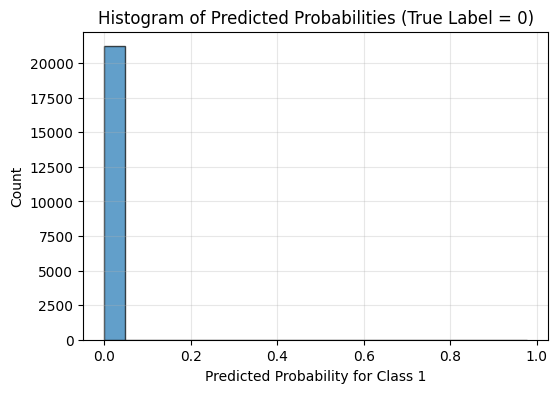

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


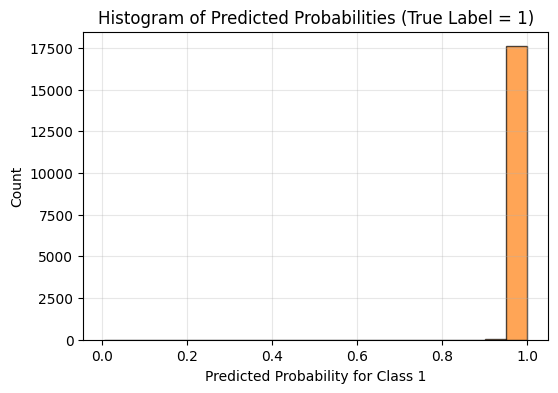

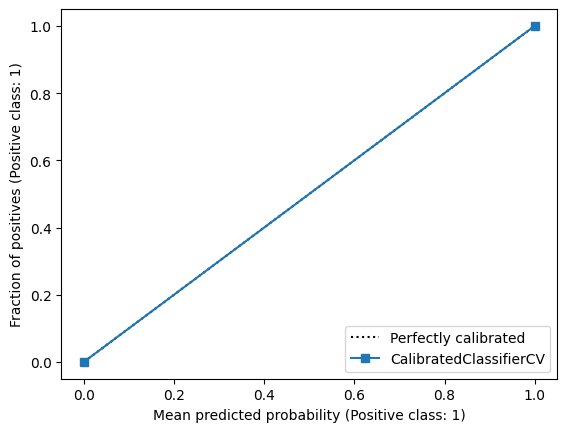

calibrating...


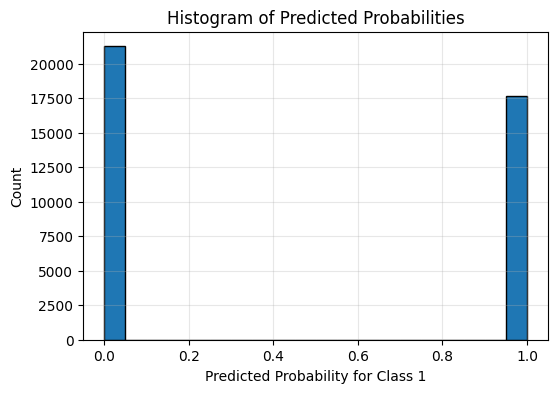

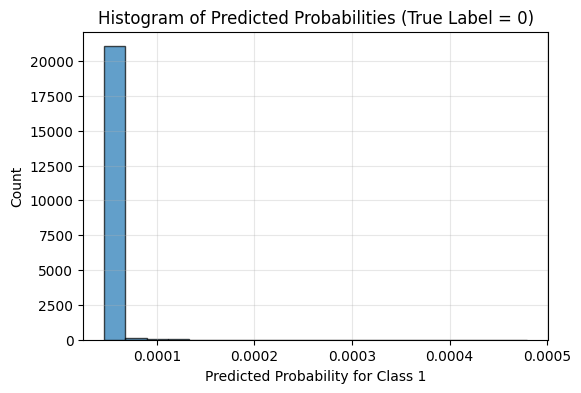

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


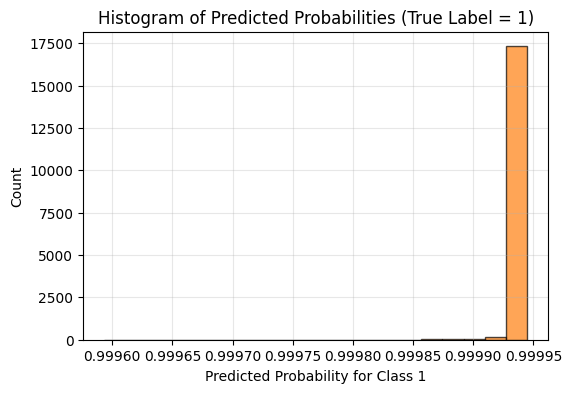

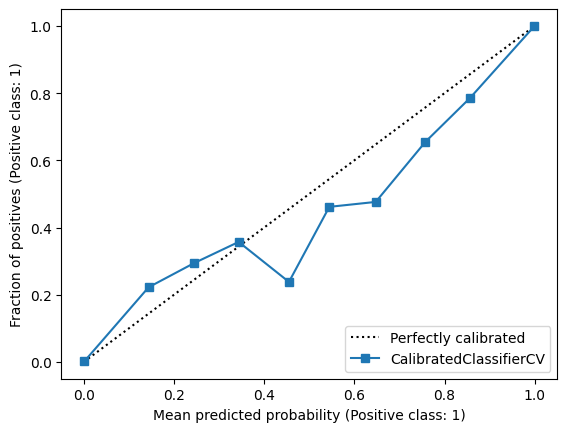

calibrating...


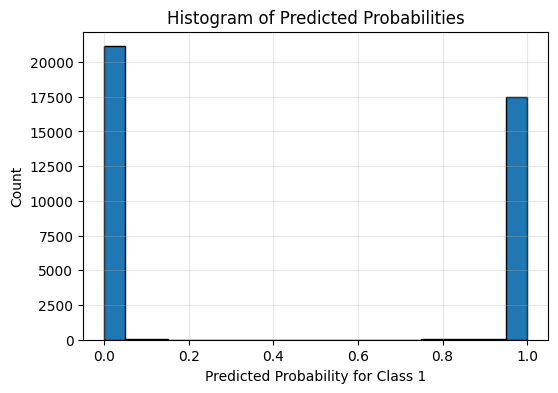

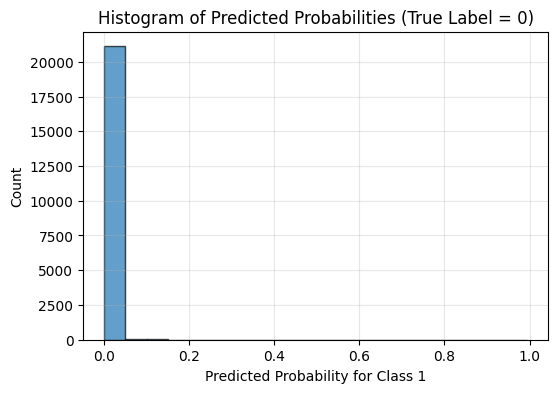

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


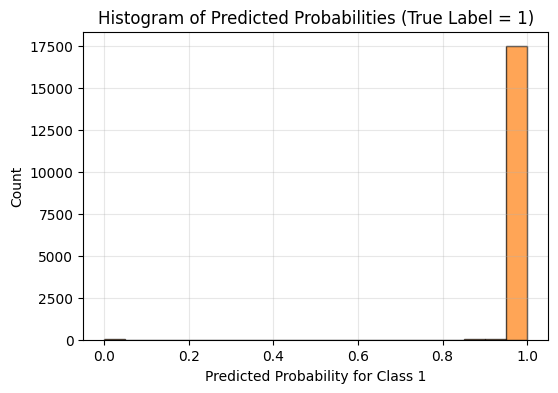

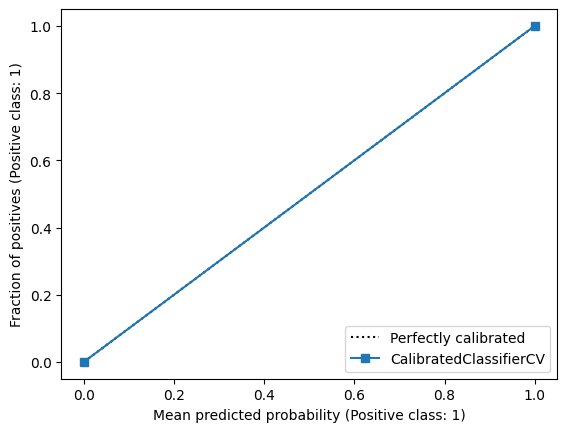

calibrating...


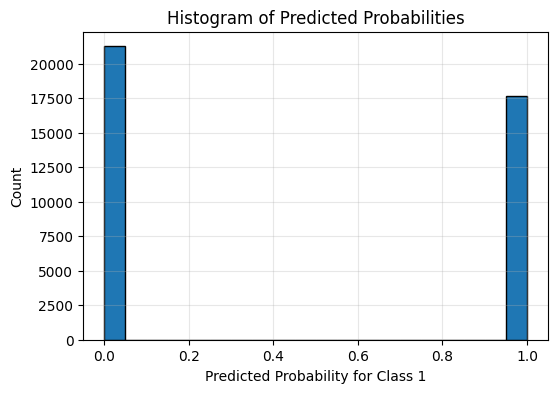

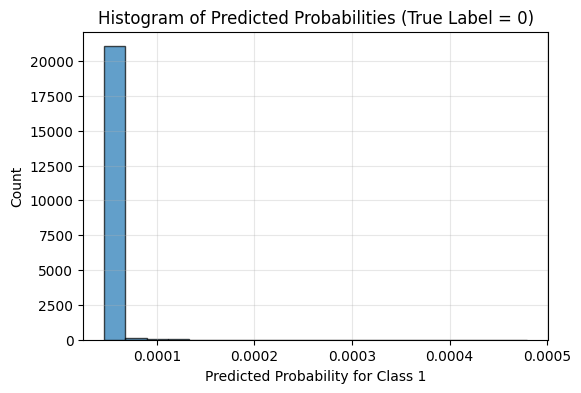

Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 16043.24it/s]

P(lab)                         -0.057188
P(vital)                       -0.188286
P(treat | lab,vital)            0.208072
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08544608367996348, 'target': 0.11318559959882944}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 8020.66it/s]

...

Evaluate set function: 16it [00:00, 15951.71it/s]

P(lab)                         -0.112391
P(vital)                       -0.015416
P(treat | lab,vital)            0.091339
P(outcome | lab,treat,vital)    0.000000
dtype: float64
Brier Score
{'source': 0.08509012105968207, 'target': 0.11497370417253965}


Evaluate set function: 0it [00:00, ?it/s]

Evaluate set function: 16it [00:00, 15857.48it/s]

P(lab)                          0.017821
P(vital)                       -0.035628
P(treat | lab,vital)           -0.060591
P(outcome | lab,treat,vital)    0.000000
dtype: float64
P(lab)                         -0.006793
P(vital)                        0.013581
P(treat | lab,vital)            0.023096
P(outcome | lab,treat,vital)   -0.000000
dtype: float64


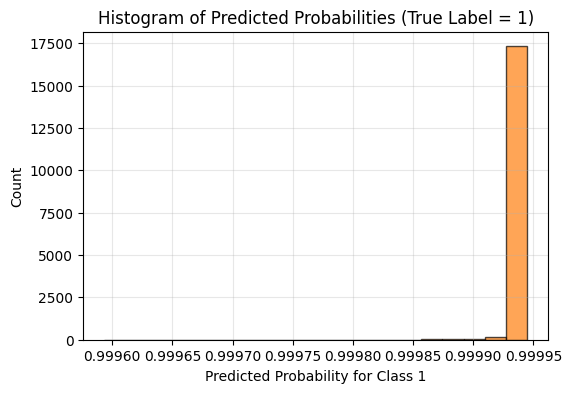

In [29]:
exp = CGExplainerDR(GRAPH, train_vars_df, test_vars_df, train_vars_df_mimic, test_vars_df_mimic,
        train_features, var_categories, target_name = 'outcome', calibrate_weight_models=True
)
explain_model(exp, model_3)
explain_model(exp, model_calib)
explain_model(exp, model_logi)
explain_model(exp, model_logi_calib)
explain_model(exp, model_mlp, auprc_torch, brier_torch)

In [30]:
print(exp.weight_model_accs)

{frozenset({'lab'}): {'roc': 0.9503028215674296, 'roc_grid': 0.8745255525811642, 'brier': 0.08889015090303201, 'clf': CalibratedClassifierCV(cv='prefit',
                       estimator=GridSearchCV(cv=3,
                                              estimator=XGBClassifier(base_score=None,
                                                                      booster=None,
                                                                      callbacks=None,
                                                                      colsample_bylevel=None,
                                                                      colsample_bynode=None,
                                                                      colsample_bytree=None,
                                                                      device=None,
                                                                      early_stopping_rounds=None,
                                                                      enable